This book is about pain surveillance and pain-grade distributions, as well as the effectiveness ratios and related z-scoring


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: set seaborn style for better visuals
sns.set(style="whitegrid")

In [2]:
df = pd.read_excel("Vaps_Hourly_Avg _EMA.xlsx", engine="openpyxl")
df.head(5)

,SUBJECT_ID,0,1,2,3,4,5,6,7,8,...,78,79,80,81,82,83,84,85,86,87
0,1,NaN,3.750000,0.0,0.0,2.0,0.0,NaN,NaN,1.0,...,NaN,1.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,11,0.0,0.000000,2.0,1.0,1.0,NaN,1.0,NaN,1.0,...,3.0,NaN,2.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN
2,17,NaN,8.000000,8.0,10.0,7.0,8.0,8.0,8.0,9.0,...,NaN,NaN,10.0,NaN,NaN,10.0,NaN,NaN,NaN,NaN
3,25,NaN,NaN,6.0,7.0,4.0,NaN,4.0,NaN,7.5,...,NaN,NaN,NaN,NaN,NaN,4.5,NaN,NaN,NaN,NaN
4,30,NaN,3.333333,0.0,8.0,0.0,9.0,8.0,0.0,0.0,...,8.0,10.0,NaN,NaN,10.0,10.0,NaN,NaN,10.0,NaN


In [3]:
demog = pd.read_excel("demog_conda1.xlsx", engine="openpyxl")
demog.head(5)

,KEY,SUBJECT,DISCARD FIXEd,EID,FIN,GROUP,TYPE,YEAR,FAC,SEX,...,ASA,PROC,PIR,START,STOP,POR,DUR,HW,HWC,PCA?
0,15841832,1,x,15841832,5932582,CEA,5-Epi (w/Opioid),2,SPOKANE,Female,...,1,Fusion Spine Instrumentation,2012-01-17 10:55:00,2012-01-17 11:36:00,2012-01-17 15:05:00,2012-01-17 15:21:00,209,43.0,E,False
1,16212574,11,x,16212574,6050119,OBA,2-Morphine-PCA,1,LEXINGTON,Male,...,2,Fusion Spine Instrumentation,2011-02-03 04:42:00,2011-02-03 06:07:00,2011-02-03 11:48:00,2011-02-03 12:27:00,341,23.0,C,True
2,16256322,17,x,16256322,6064105,OBA,3-Hydromorphone-PCA,1,LEXINGTON,Female,...,2,Fusion Spine Instrumentation,2011-03-10 04:40:00,2011-03-10 05:59:00,2011-03-10 12:23:00,2011-03-10 12:49:00,384,15.0,B,True
3,16318565,25,x,16318565,6084054,OBA,3-Hydromorphone-PCA,1,PORTLAND,Female,...,2,Fusion Spine Instrumentation,2011-03-07 07:28:00,2011-03-07 08:25:00,2011-03-07 12:52:00,2011-03-07 13:15:00,267,18.0,B,True
4,16332561,30,x,16332561,6087383,OBA,2-Morphine-PCA,1,LEXINGTON,Female,...,1,Fusion Spine Instrumentation,2011-03-08 05:13:00,2011-03-08 06:33:00,2011-03-08 10:42:00,2011-03-08 11:12:00,249,15.0,B,True


In [4]:
type_restore_map = {
    '2-Morphine-PCA': '1-Morphine-PCA',
    '3-Hydromorphone-PCA': '2-Hydromorphone-PCA',
    '5-Epi (w/Opioid)': '3-Epi (w/Opioid)',
    '6-Block w/Opioid': '4-Block w/Opioid'
}


demog['TYPE'] = demog['TYPE'].replace(type_restore_map)


In [5]:
demog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2371 entries, 0 to 2370
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   KEY            2371 non-null   int64         
 1   SUBJECT        2371 non-null   int64         
 2   DISCARD FIXEd  737 non-null    object        
 3   EID            2371 non-null   int64         
 4   FIN            2371 non-null   int64         
 5   GROUP          2371 non-null   object        
 6   TYPE           2371 non-null   object        
 7   YEAR           2371 non-null   int64         
 8   FAC            2371 non-null   object        
 9   SEX            2371 non-null   object        
 10  RACE           2371 non-null   object        
 11  AGE            2371 non-null   float64       
 12  HT             2371 non-null   float64       
 13  WT             2371 non-null   float64       
 14  BMI            2371 non-null   float64       
 15  ADMIT          2371 n

In [6]:
# Identify object columns
object_cols = df.select_dtypes(include='object').columns

# Convert each to category
df[object_cols] = df[object_cols].astype('category')


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2361 entries, 0 to 2360
Data columns (total 89 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SUBJECT_ID  2361 non-null   int64  
 1   0           1004 non-null   float64
 2   1           1139 non-null   float64
 3   2           962 non-null    float64
 4   3           1016 non-null   float64
 5   4           1005 non-null   float64
 6   5           969 non-null    float64
 7   6           993 non-null    float64
 8   7           1007 non-null   float64
 9   8           891 non-null    float64
 10  9           931 non-null    float64
 11  10          870 non-null    float64
 12  11          922 non-null    float64
 13  12          869 non-null    float64
 14  13          896 non-null    float64
 15  14          888 non-null    float64
 16  15          979 non-null    float64
 17  16          938 non-null    float64
 18  17          985 non-null    float64
 19  18          1075 non-null  

In [8]:
# Drop SUBJECT, keep EID as identifier, melt other columns
melted_df = df.melt(
    id_vars=['SUBJECT_ID'],
    var_name='POH',
    value_name='HOURLY_AVG_VAPS'
)

print(melted_df.head())


   SUBJECT_ID POH  HOURLY_AVG_VAPS
0           1   0              NaN
1          11   0              0.0
2          17   0              NaN
3          25   0              NaN
4          30   0              NaN


In [7]:
# Define the columns to bring in from demog
demog_cols = ['SUBJECT_ID', 'GROUP', 'TYPE', 'YEAR', 'FAC', 'SEX', 'RACE', 'AGE', 'BMI', 'HW', 'ASA','DSCPOH']

# Perform the merge
df = df.merge(demog[demog_cols], on='EID', how='left')


In [9]:
# Step 1: Group span data by EID and sum DURATION
span_summary = df.groupby('EID')['DURATION'].sum().reset_index(name='total_span_duration')

# Step 2: Extract unique demographic info per EID
demog_cols = ['EID', 'GROUP', 'TYPE', 'YEAR', 'FAC', 'SEX', 'RACE', 'AGE', 'BMI', 'HW', 'ASA', 'DSCPOH']
demog_summary = df[demog_cols].drop_duplicates(subset='EID')

# Step 3: Merge span totals with demographics
patient_summary = demog_summary.merge(span_summary, on='EID', how='left')

# Step 4: Calculate coverage denominator (min of 88 or DSCPOR)
patient_summary['coverage_window'] = patient_summary['DSCPOH'].clip(upper=88)

# Step 5: Compute coverage ratio
patient_summary['coverage_ratio'] = patient_summary['total_span_duration'] / patient_summary['coverage_window']


In [10]:
patient_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2361 entries, 0 to 2360
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   EID                  2361 non-null   int64  
 1   GROUP                2361 non-null   object 
 2   TYPE                 2361 non-null   object 
 3   YEAR                 2361 non-null   int64  
 4   FAC                  2361 non-null   object 
 5   SEX                  2361 non-null   object 
 6   RACE                 2361 non-null   object 
 7   AGE                  2361 non-null   float64
 8   BMI                  2361 non-null   float64
 9   HW                   2361 non-null   float64
 10  ASA                  2361 non-null   int64  
 11  DSCPOH               2361 non-null   float64
 12  total_span_duration  2361 non-null   float64
 13  coverage_window      2361 non-null   float64
 14  coverage_ratio       2361 non-null   float64
dtypes: float64(7), int64(3), object(5)
mem

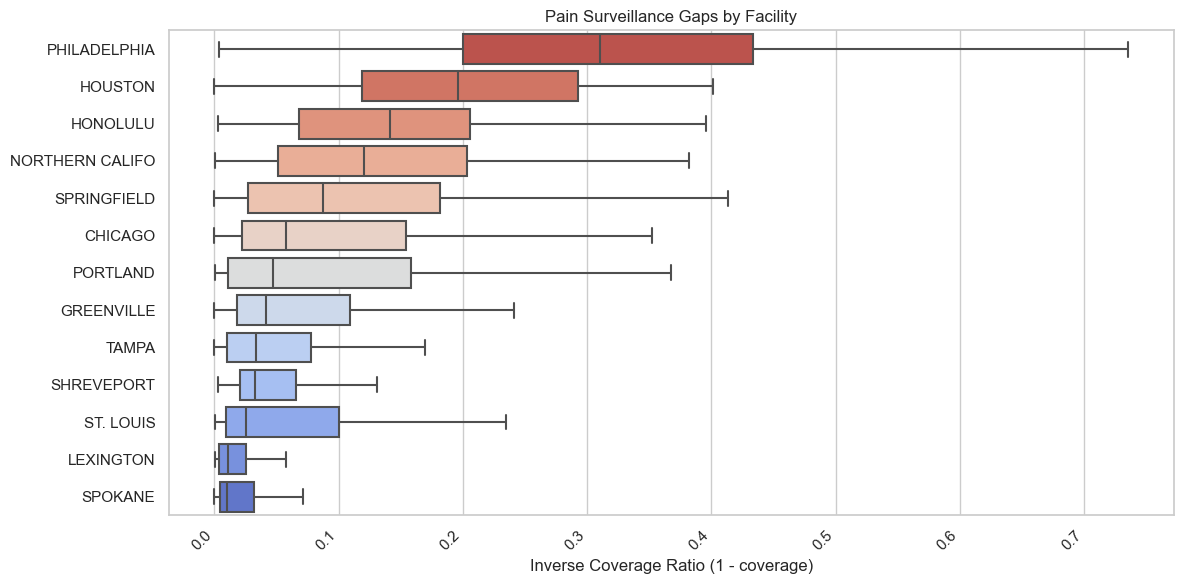

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Create inverse coverage column
patient_summary['inverse_coverage'] = 1 - patient_summary['coverage_ratio']

# Step 2: Rank facilities by median inverse coverage
fac_order = (
    patient_summary.groupby('FAC')['inverse_coverage']
    .median()
    .sort_values(ascending=False)
    .index
)

# Step 3: Create boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=patient_summary,
    y='FAC',
    x='inverse_coverage',
    order=fac_order,
    palette='coolwarm_r',
    showfliers = False
)

# Step 4: Customize plot
plt.xticks(rotation=45, ha='right')
plt.ylabel('')
plt.xlabel('Inverse Coverage Ratio (1 - coverage)')
plt.title('Pain Surveillance Gaps by Facility')
plt.tight_layout()
plt.show()


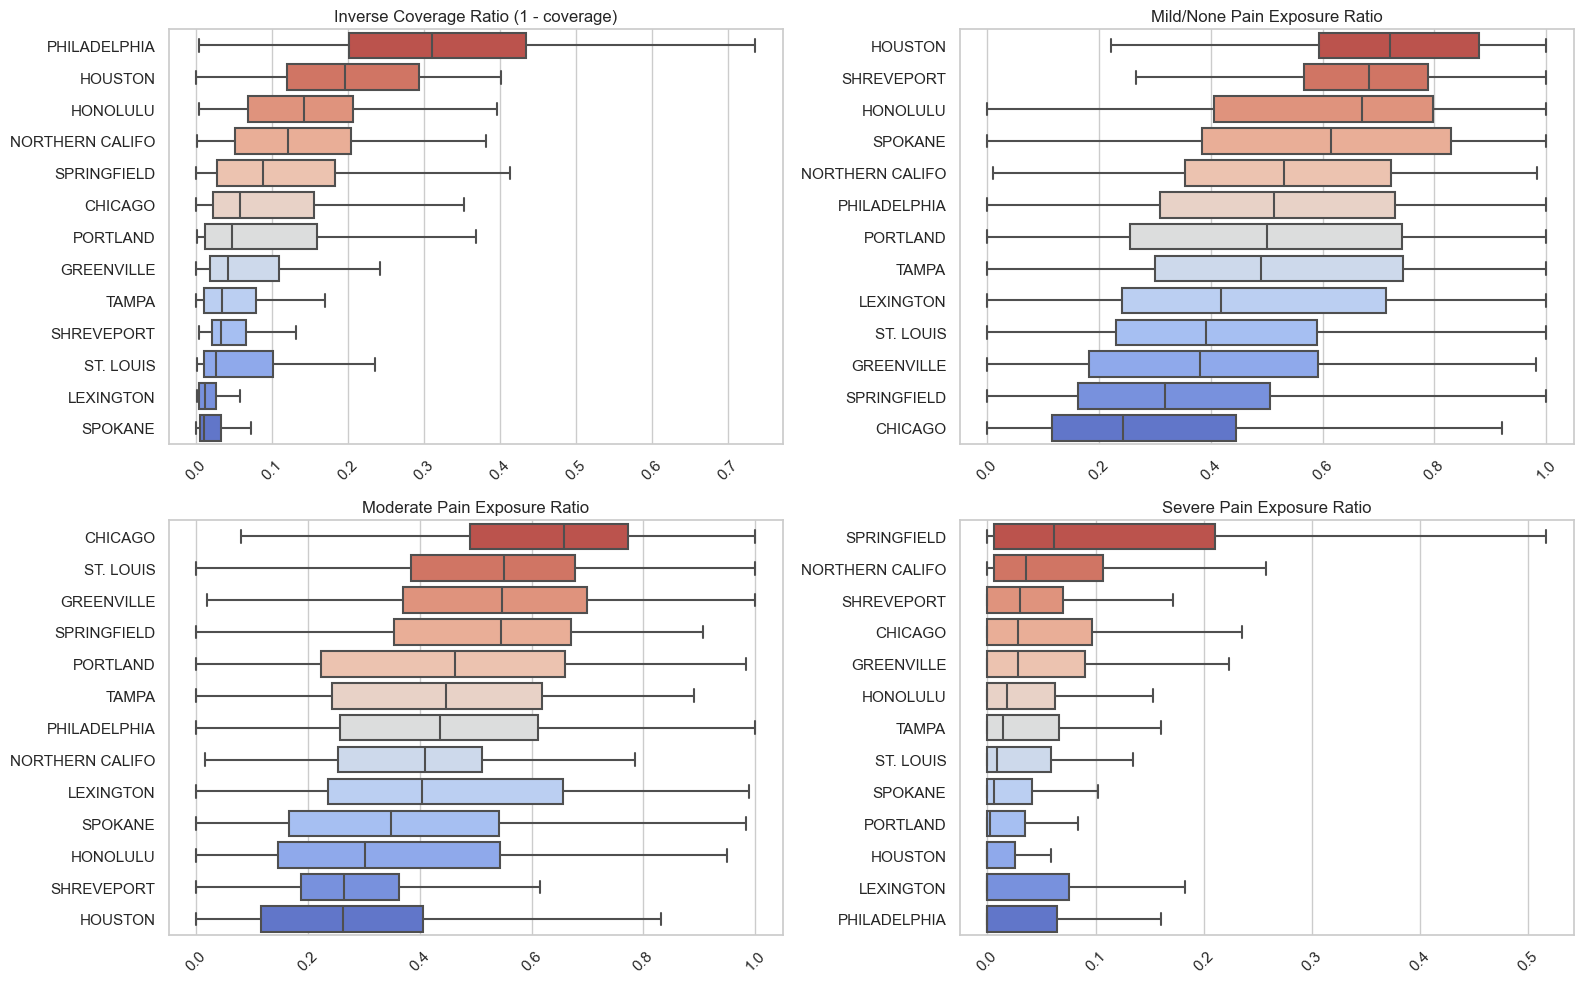

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Create inverse coverage column
patient_summary['inverse_coverage'] = 1 - patient_summary['coverage_ratio']

# Step 2: Define metrics and titles
metrics = [
    ('inverse_coverage', 'Inverse Coverage Ratio (1 - coverage)'),
    ('mild_duration_ratio', 'Mild/None Pain Exposure Ratio'),
    ('moderate_duration_ratio', 'Moderate Pain Exposure Ratio'),
    ('severe_duration_ratio', 'Severe Pain Exposure Ratio')
]

# Step 3: Set up 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Step 4: Plot each boxplot
for i, (metric, title) in enumerate(metrics):
    # Rank FACs by median of current metric
    fac_order = (
        patient_summary.groupby('FAC')[metric]
        .median()
        .sort_values(ascending=False)
        .index
    )
    
    sns.boxplot(
        data=patient_summary,
        y='FAC',
        x=metric,
        order=fac_order,
        palette='coolwarm_r',
        showfliers=False,
        ax=axes[i]
    )
    
    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Step 5: Final layout
plt.tight_layout()
plt.show()


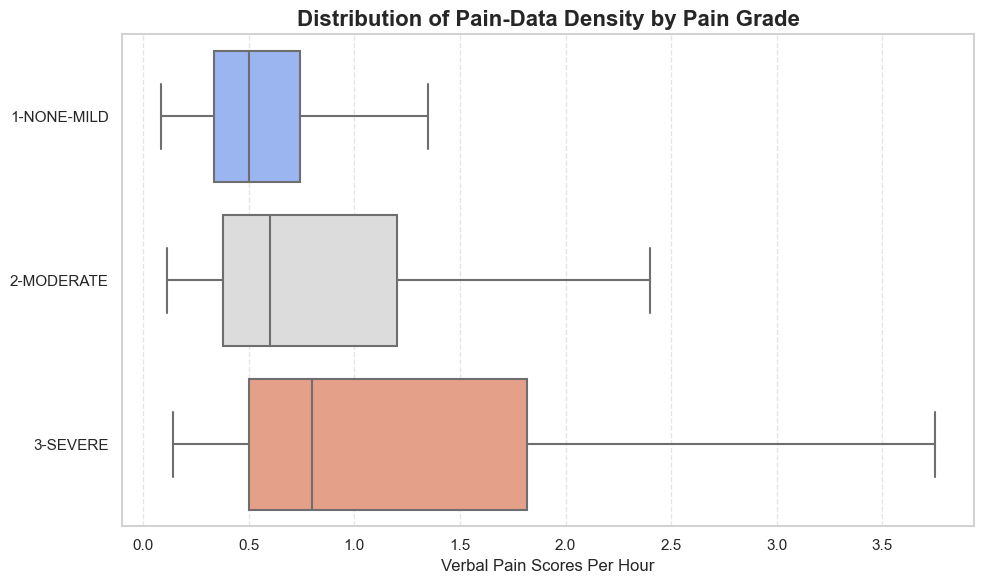

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure ROW GRADE is categorical
df['GRADE'] = df['GRADE'].astype('category')

# Create boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='DENSITY',
    y='GRADE',
    palette='coolwarm',
    showfliers=False
)

# Labeling
plt.xlabel('Verbal Pain Scores Per Hour')
plt.ylabel('')
plt.title('Distribution of Pain-Data Density by Pain Grade', fontsize=16, weight='bold')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [15]:
from scipy.stats import kruskal, mannwhitneyu
import pandas as pd

# Prepare data
grades = df['GRADE'].cat.categories.tolist()
density_groups = [df[df['GRADE'] == grade]['DENSITY'].dropna() for grade in grades]

# Kruskal-Wallis test
kw_stat, kw_p = kruskal(*density_groups)

# Pairwise Mann–Whitney U tests
pairwise_results = [{
    'Test': 'Kruskal-Wallis',
    'Comparison': 'All Grades',
    'Statistic': f'{kw_stat:.2f}',
    'p-value': f'{kw_p:.4f}'
}]
for i in range(len(grades)):
    for j in range(i + 1, len(grades)):
        stat, p = mannwhitneyu(density_groups[i], density_groups[j], alternative='two-sided')
        pairwise_results.append({
            'Test': 'Mann-Whitney U',
            'Comparison': f'{grades[i]} vs {grades[j]}',
            'Statistic': f'{stat:.2f}',
            'p-value': f'{p:.4f}'
        })

# Create styled table
summary_df = pd.DataFrame(pairwise_results)
summary_df.style.set_caption(
    "<strong>Statistical Comparison of Pain-Data Density by Pain Grade</strong><br><br>"
    "• Kruskal-Wallis test for overall grade differences<br>"
    "• Mann–Whitney U for pairwise comparisons"
)\
    .applymap(lambda val: 'background-color: lightgreen' if isinstance(val, str) and val.replace('.', '', 1).isdigit() and float(val) < 0.05 else '', subset=['p-value'])\
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "16px"), ("font-weight", "bold")]
    }])



,Test,Comparison,Statistic,p-value
0,Kruskal-Wallis,All Grades,2028.42,0.0000
1,Mann-Whitney U,1-NONE-MILD vs 2-MODERATE,81581507.50,0.0000
2,Mann-Whitney U,1-NONE-MILD vs 3-SEVERE,15718224.00,0.0000
3,Mann-Whitney U,2-MODERATE vs 3-SEVERE,24555837.00,0.0000


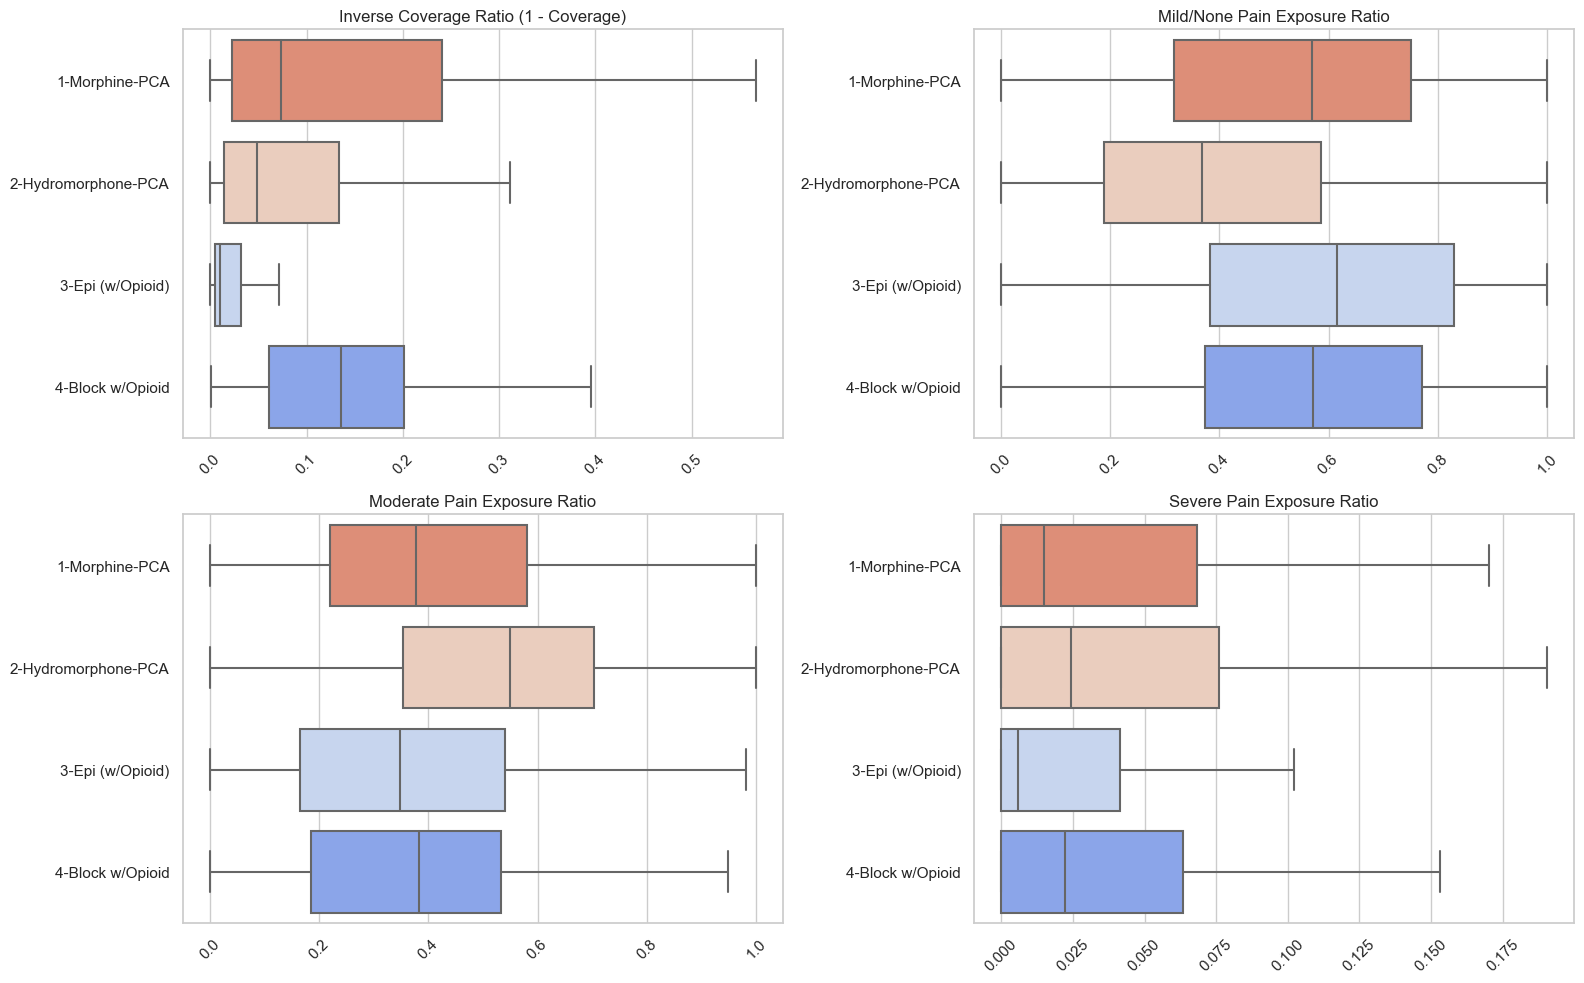

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Create inverse coverage column
patient_summary['inverse_coverage'] = 1 - patient_summary['coverage_ratio']
# Extract leading integer from TYPE
patient_summary['TYPE_ORDER'] = patient_summary['TYPE'].str.extract(r'^(\d+)').astype(int)

type_order = (
    patient_summary[['TYPE', 'TYPE_ORDER']]
    .drop_duplicates()
    .sort_values('TYPE_ORDER')
    ['TYPE']
    .tolist()
)



# Step 2: Define metrics and titles
metrics = [
    ('inverse_coverage', 'Inverse Coverage Ratio (1 - Coverage)'),
    ('mild_duration_ratio', 'Mild/None Pain Exposure Ratio'),
    ('moderate_duration_ratio', 'Moderate Pain Exposure Ratio'),
    ('severe_duration_ratio', 'Severe Pain Exposure Ratio')
]

# Step 3: Set up 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

 #Step 4: Plot each boxplot
for i, (metric, title) in enumerate(metrics):
    # Rank FACs by median of current metric
    fac_order = (
        patient_summary.groupby('TYPE')[metric]
        .median()
        .sort_values(ascending=False)
        .index
                )
    
    sns.boxplot(
        data=patient_summary,
        y='TYPE',
        x=metric,
        order=type_order,
        palette='coolwarm_r',
        showfliers=False,
        ax=axes[i]
    )
    
    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Step 5: Final layout
plt.tight_layout()
plt.show()


In [17]:
import pandas as pd
from scipy.stats import mannwhitneyu, ks_2samp
import numpy as np

# Function to calculate Cliff's Delta
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    total = nx * ny
    greater = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (greater - less) / total

# Function to highlight p-values
def highlight_pvals(val):
    try:
        val = float(val)
        if val < 0.05:
            return 'background-color: lightgreen'
        elif val >= 0.05:
            return 'background-color: lightpink'
    except:
        return ''

# Setup
types = patient_summary['TYPE'].dropna().unique()
results = []

for i, type1 in enumerate(types):
    for type2 in types[i+1:]:
        x = patient_summary[patient_summary['TYPE'] == type1]['mild_duration_ratio'].dropna()
        y = patient_summary[patient_summary['TYPE'] == type2]['mild_duration_ratio'].dropna()
        if len(x) == 0 or len(y) == 0:
            continue

        # Mann–Whitney U
        u_stat, u_p = mannwhitneyu(x, y, alternative='two-sided')

        # Kolmogorov–Smirnov
        ks_stat, ks_p = ks_2samp(x, y)

        # Cliff's Delta
        delta = cliffs_delta(x, y)

        # Median difference
        x_median = x.median()
        y_median = y.median()
        pct_diff = ((x_median - y_median)) if y_median != 0 else None

        # Clinical interpretation
        # Clinical interpretation
        # Clinical interpretation
        if abs(x_median - y_median) >= 0.10:
            clinical = "Clinically significant"
        elif abs(x_median - y_median) >= 0.05:
            clinical = "Possibly significant"
        else:
            clinical = "Insignificant"

        results.append({
            "TYPE A": type1,
            "TYPE B": type2,
            "Mann–Whitney p": round(u_p, 4),
            "K–S p": round(ks_p, 4),
            "Cliff's Delta": round(delta, 3),
            "Median A": round(x_median, 4),
            "Median B": round(y_median, 4),
            "% Difference": round(pct_diff * 100, 2) if pct_diff is not None else None,
            "Clinical Interpretation": clinical
        })

# Create summary table
summary_df = pd.DataFrame(results)

# Style and display
summary_df.style.set_caption(
    "<strong>Statistical and Clinical Comparison of Mild_Duration_Ratio by TYPE</strong><br>"
    "<br>"
    "• Mann–Whitney U test (median difference)<br>"
    "• Kolmogorov–Smirnov test (distributional difference)<br>"
    "• Cliff’s Delta (effect size)<br>"
    "<br>"
    "• ≥ 10% increase in Mild/No Pain Intervals → Clinically significant<br>"
    "• 5+% increase in Mild/No Pain Intervals   → Possibly significant<br>"
    "• < 5% increase in Mild/No Pain Intervals  → Not clinically significant"
)\
    .format({
        "Mann–Whitney p": "{:.4f}",
        "K–S p": "{:.4f}",
        "% Difference": "{:+.2f}%"
    })\
    .applymap(highlight_pvals, subset=["Mann–Whitney p", "K–S p"])\
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "16px"), ("font-weight", "bold")]
    }])


,TYPE A,TYPE B,Mann–Whitney p,K–S p,Cliff's Delta,Median A,Median B,% Difference,Clinical Interpretation
0,3-Epi (w/Opioid),1-Morphine-PCA,0.0071,0.0076,0.106000,0.615200,0.570500,+4.47%,Insignificant
1,3-Epi (w/Opioid),2-Hydromorphone-PCA,0.0000,0.0000,0.375000,0.615200,0.368900,+24.63%,Clinically significant
2,3-Epi (w/Opioid),4-Block w/Opioid,0.7808,0.5215,0.020000,0.615200,0.571900,+4.33%,Insignificant
3,1-Morphine-PCA,2-Hydromorphone-PCA,0.0000,0.0000,0.287000,0.570500,0.368900,+20.16%,Clinically significant
4,1-Morphine-PCA,4-Block w/Opioid,0.1305,0.0944,-0.096000,0.570500,0.571900,-0.14%,Insignificant
5,2-Hydromorphone-PCA,4-Block w/Opioid,0.0000,0.0000,-0.401000,0.368900,0.571900,-20.30%,Clinically significant


In [18]:
import pandas as pd
from scipy.stats import mannwhitneyu, ks_2samp
import numpy as np

# Function to calculate Cliff's Delta
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    total = nx * ny
    greater = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (greater - less) / total

# Function to highlight p-values
def highlight_pvals(val):
    try:
        val = float(val)
        if val < 0.05:
            return 'background-color: lightgreen'
        elif val >= 0.05:
            return 'background-color: lightpink'
    except:
        return ''

# Setup
types = patient_summary['TYPE'].dropna().unique()
results = []

for i, type1 in enumerate(types):
    for type2 in types[i+1:]:
        x = patient_summary[patient_summary['TYPE'] == type1]['moderate_duration_ratio'].dropna()
        y = patient_summary[patient_summary['TYPE'] == type2]['moderate_duration_ratio'].dropna()
        if len(x) == 0 or len(y) == 0:
            continue

        # Mann–Whitney U
        u_stat, u_p = mannwhitneyu(x, y, alternative='two-sided')

        # Kolmogorov–Smirnov
        ks_stat, ks_p = ks_2samp(x, y)

        # Cliff's Delta
        delta = cliffs_delta(x, y)

        # Median difference
        x_median = x.median()
        y_median = y.median()
        #pct_diff = ((y_median - x_median) / x_median) if x_median != 0 else None
        pct_diff = ((x_median - y_median)) if y_median != 0 else None

        # Clinical interpretation
        if abs(x_median - y_median) >= 0.10:
            clinical = "Clinically significant"
        elif abs(x_median - y_median) >= 0.05:
            clinical = "Possibly significant"
        else:
            clinical = "Insignificant"


        results.append({
            "TYPE A": type1,
            "TYPE B": type2,
            "Mann–Whitney p": round(u_p, 4),
            "K–S p": round(ks_p, 4),
            "Cliff's Delta": round(delta, 3),
            "Median A": round(x_median, 4),
            "Median B": round(y_median, 4),
            "% Difference": round(pct_diff * 100, 2) if pct_diff is not None else None,
            "Clinical Interpretation": clinical
        })

# Create summary table
summary_df = pd.DataFrame(results)

# Style and display
summary_df.style.set_caption(
    "<strong>Statistical and Clinical Comparison of Moderate_Duration_Ratio by TYPE</strong><br>"
    "<br>"
    "• Mann–Whitney U test (median difference)<br>"
    "• Kolmogorov–Smirnov test (distributional difference)<br>"
    "• Cliff’s Delta (effect size)<br>"
    "<br>"
    "• ≥ 10% reduction in Moderate Pain Intervals → Clinically significant<br>"
    "• 5+% reduction in Moderate Pain Intervals   → Possibly significant<br>"
    "• < 5% reduction in Moderate Pain Intervals  → Not clinically significant"
)\
    .format({
        "Mann–Whitney p": "{:.4f}",
        "K–S p": "{:.4f}",
        "% Difference": "{:+.2f}%"
    })\
    .applymap(highlight_pvals, subset=["Mann–Whitney p", "K–S p"])\
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "16px"), ("font-weight", "bold")]
    }])


,TYPE A,TYPE B,Mann–Whitney p,K–S p,Cliff's Delta,Median A,Median B,% Difference,Clinical Interpretation
0,3-Epi (w/Opioid),1-Morphine-PCA,0.0314,0.0353,-0.085000,0.348000,0.377400,-2.94%,Insignificant
1,3-Epi (w/Opioid),2-Hydromorphone-PCA,0.0000,0.0000,-0.371000,0.348000,0.550300,-20.23%,Clinically significant
2,3-Epi (w/Opioid),4-Block w/Opioid,0.9128,0.9046,-0.008000,0.348000,0.383600,-3.56%,Insignificant
3,1-Morphine-PCA,2-Hydromorphone-PCA,0.0000,0.0000,-0.299000,0.377400,0.550300,-17.29%,Clinically significant
4,1-Morphine-PCA,4-Block w/Opioid,0.2133,0.3664,0.079000,0.377400,0.383600,-0.62%,Insignificant
5,2-Hydromorphone-PCA,4-Block w/Opioid,0.0000,0.0000,0.386000,0.550300,0.383600,+16.67%,Clinically significant


In [19]:
import pandas as pd
from scipy.stats import mannwhitneyu, ks_2samp
import numpy as np

# Function to calculate Cliff's Delta
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    total = nx * ny
    greater = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (greater - less) / total

# Function to highlight p-values
def highlight_pvals(val):
    try:
        val = float(val)
        if val < 0.05:
            return 'background-color: lightgreen'
        elif val >= 0.05:
            return 'background-color: lightpink'
    except:
        return ''

# Setup
types = patient_summary['TYPE'].dropna().unique()
results = []

for i, type1 in enumerate(types):
    for type2 in types[i+1:]:
        x = patient_summary[patient_summary['TYPE'] == type1]['severe_duration_ratio'].dropna()
        y = patient_summary[patient_summary['TYPE'] == type2]['severe_duration_ratio'].dropna()
        if len(x) == 0 or len(y) == 0:
            continue

        # Mann–Whitney U
        u_stat, u_p = mannwhitneyu(x, y, alternative='two-sided')

        # Kolmogorov–Smirnov
        ks_stat, ks_p = ks_2samp(x, y)

        # Cliff's Delta
        delta = cliffs_delta(x, y)

        # Median difference
        x_median = x.median()
        y_median = y.median()
        #pct_diff = ((y_median - x_median) / x_median) if x_median != 0 else None
        pct_diff = ((x_median - y_median)) if y_median != 0 else None

        # Clinical interpretation
        if abs(x_median - y_median) >= 0.02:
            clinical = "Clinically significant"
        elif abs(x_median - y_median) >= 0.01:
            clinical = "Possibly significant"
        else:
            clinical = "Insignificant"



        results.append({
            "TYPE A": type1,
            "TYPE B": type2,
            "Mann–Whitney p": round(u_p, 4),
            "K–S p": round(ks_p, 4),
            "Cliff's Delta": round(delta, 3),
            "Median A": round(x_median, 4),
            "Median B": round(y_median, 4),
            "% Difference": round(pct_diff * 100, 2) if pct_diff is not None else None,
            "Clinical Interpretation": clinical
        })

# Create summary table
summary_df = pd.DataFrame(results)

# Style and display
summary_df.style.set_caption(
    "<strong>Statistical and Clinical Comparison of Severe_Duration_Ratio by TYPE</strong><br>"
    "<br>"
    "• Mann–Whitney U test (median difference)<br>"
    "• Kolmogorov–Smirnov test (distributional difference)<br>"
    "• Cliff’s Delta (effect size)<br>"
    "<br>"
    "• ≥ 2% reduction in Severe Pain Intervals → Clinically significant<br>"
    "• 1+% reduction in Severe Pain Intervals  → Possibly significant<br>"
    "• < 1% reduction in Severe Pain Intervals → Not clinically significant"
)\
    .format({
        "Mann–Whitney p": "{:.4f}",
        "K–S p": "{:.4f}",
        "% Difference": "{:+.2f}%"
    })\
    .applymap(highlight_pvals, subset=["Mann–Whitney p", "K–S p"])\
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "16px"), ("font-weight", "bold")]
    }])


,TYPE A,TYPE B,Mann–Whitney p,K–S p,Cliff's Delta,Median A,Median B,% Difference,Clinical Interpretation
0,3-Epi (w/Opioid),1-Morphine-PCA,0.0250,0.0005,-0.085000,0.005700,0.014800,-0.91%,Insignificant
1,3-Epi (w/Opioid),2-Hydromorphone-PCA,0.0002,0.0000,-0.149000,0.005700,0.024200,-1.85%,Possibly significant
2,3-Epi (w/Opioid),4-Block w/Opioid,0.0373,0.0379,-0.142000,0.005700,0.022300,-1.66%,Possibly significant
3,1-Morphine-PCA,2-Hydromorphone-PCA,0.0212,0.0439,-0.058000,0.014800,0.024200,-0.94%,Insignificant
4,1-Morphine-PCA,4-Block w/Opioid,0.5540,0.3469,-0.036000,0.014800,0.022300,-0.76%,Insignificant
5,2-Hydromorphone-PCA,4-Block w/Opioid,0.6556,0.8011,0.028000,0.024200,0.022300,+0.19%,Insignificant


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33413 entries, 0 to 33412
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   EID             33413 non-null  int64   
 1   GRADE           33413 non-null  category
 2   START           33413 non-null  float64 
 3   COUNT           33413 non-null  int64   
 4   STOP            33413 non-null  float64 
 5   DURATION        33413 non-null  float64 
 6   INTERVAL PTS    33413 non-null  int64   
 7   SPAN AVG SCORE  33413 non-null  float64 
 8   NATURAL         33413 non-null  bool    
 9   CAP             2361 non-null   category
 10  TIMED OUT       2724 non-null   category
 11  DENSITY         32743 non-null  float64 
 12  GROUP           33413 non-null  object  
 13  TYPE            33413 non-null  object  
 14  YEAR            33413 non-null  int64   
 15  FAC             33413 non-null  object  
 16  SEX             33413 non-null  object  
 17  RACE        

In [21]:
import pandas as pd

# Step 1: Aggregate total scores by EID
score_counts = df.groupby('EID')['COUNT'].sum().reset_index()
score_counts.rename(columns={'COUNT': 'Total_Scores'}, inplace=True)

# Step 2: Merge into patient_summary
patient_summary = patient_summary.merge(score_counts, on='EID', how='left')
patient_summary['Total_Scores'] = patient_summary['Total_Scores'].fillna(0)

# Step 3: Calculate Total_Density
patient_summary['Total_Density'] = patient_summary['Total_Scores'] / patient_summary['total_span_duration']


In [22]:
patient_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2361 entries, 0 to 2360
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EID                      2361 non-null   int64  
 1   GROUP                    2361 non-null   object 
 2   TYPE                     2361 non-null   object 
 3   YEAR                     2361 non-null   int64  
 4   FAC                      2361 non-null   object 
 5   SEX                      2361 non-null   object 
 6   RACE                     2361 non-null   object 
 7   AGE                      2361 non-null   float64
 8   BMI                      2361 non-null   float64
 9   HW                       2361 non-null   float64
 10  ASA                      2361 non-null   int64  
 11  DSCPOH                   2361 non-null   float64
 12  total_span_duration      2361 non-null   float64
 13  coverage_window          2361 non-null   float64
 14  coverage_ratio          

In [23]:
import pandas as pd

# Step 1: Filter for Morphine PCA
filtered_df = patient_summary[patient_summary['TYPE'] == '1-Morphine-PCA']

# Step 2: Group by FAC and calculate metrics
grouped = filtered_df.groupby('FAC').agg({
    'coverage_ratio': 'mean',
    'Total_Density': 'mean',
    'mild_duration_ratio': 'mean',
    'severe_duration_ratio': 'mean'
}).reset_index()

# Step 3: Compute weighted composite score
grouped['composite_score'] = (
    2.0 * grouped['coverage_ratio'] +
    2.0 * grouped['Total_Density'] +
    1.0 * grouped['mild_duration_ratio'] -
    1.0 * grouped['severe_duration_ratio']
)

# Step 4: Rank facilities
ranked = grouped.sort_values(by='composite_score', ascending=False)

# Step 5: Style and display
ranked.style.set_caption(
    "<strong>🏆 Standardized Pain Control Ranking (Morphine PCA)</strong><br><br>"
    "• Surveillance metrics (Coverage, Density) are overweighted<br>"
    "• Mild pain rewarded, severe pain penalized<br>"
    "• Composite score = 2×Coverage + 2×Density + Mild − Severe"
)\
    .highlight_max(subset=['composite_score'], color='lightgreen')\
    .format({
        'coverage_ratio': '{:.2f}',
        'Total_Density': '{:.2f}',
        'mild_duration_ratio': '{:.2f}',
        'severe_duration_ratio': '{:.2f}',
        'composite_score': '{:.2f}'
    })\
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "16px"), ("font-weight", "bold")]
    }])


,FAC,coverage_ratio,Total_Density,mild_duration_ratio,severe_duration_ratio,composite_score
2,LEXINGTON,0.96,0.69,0.49,0.06,3.74
5,SHREVEPORT,0.94,0.54,0.67,0.05,3.57
0,GREENVILLE,0.93,0.56,0.42,0.09,3.32
8,TAMPA,0.92,0.48,0.42,0.10,3.12
4,PORTLAND,0.89,0.44,0.50,0.05,3.10
7,ST. LOUIS,0.90,0.50,0.39,0.09,3.09
6,SPRINGFIELD,0.85,0.45,0.34,0.14,2.81
1,HOUSTON,0.76,0.31,0.69,0.02,2.80
3,PHILADELPHIA,0.66,0.28,0.51,0.04,2.35


In [24]:
import pandas as pd

# Step 1: Filter for Morphine PCA
#filtered_df = patient_summary[patient_summary['TYPE'] == '1-Morphine-PCA']

# Step 2: Group by FAC and calculate metrics
grouped = patient_summary.groupby('FAC').agg({
    'coverage_ratio': 'mean',
    'Total_Density': 'mean',
    'mild_duration_ratio': 'mean',
    'severe_duration_ratio': 'mean'
}).reset_index()

# Step 3: Compute weighted composite score
grouped['composite_score'] = (
    2.0 * grouped['coverage_ratio'] +
    2 * grouped['Total_Density'] +
    1 * grouped['mild_duration_ratio'] -
    1 * grouped['severe_duration_ratio']
)

# Step 4: Rank facilities
ranked = grouped.sort_values(by='composite_score', ascending=False)

# Step 5: Style and display
ranked.style.set_caption(
    "<strong> Standardized Pain Control Ranking</strong><br><br>"
    "• Surveillance metrics (Coverage, Density) are overweighted<br>"
    "• Mild pain rewarded, severe pain penalized<br>"
    "• (Coverage_Ratio * 2) + (Total_Density * 2) + Mild_Ratio − Severe_Ratio"
)\
    .highlight_max(subset=['composite_score'], color='lightgreen')\
    .format({
        'coverage_ratio': '{:.2f}',
        'Total_Density': '{:.2f}',
        'mild_duration_ratio': '{:.2f}',
        'severe_duration_ratio': '{:.2f}',
        'composite_score': '{:.2f}'
    })\
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "16px"), ("font-weight", "bold")]
    }])


,FAC,coverage_ratio,Total_Density,mild_duration_ratio,severe_duration_ratio,composite_score
4,LEXINGTON,0.96,0.70,0.48,0.08,3.72
9,SPOKANE,0.97,0.56,0.58,0.05,3.60
8,SHREVEPORT,0.94,0.54,0.67,0.05,3.57
12,TAMPA,0.93,0.53,0.51,0.07,3.34
1,GREENVILLE,0.92,0.55,0.40,0.07,3.26
11,ST. LOUIS,0.92,0.52,0.42,0.06,3.23
7,PORTLAND,0.89,0.45,0.50,0.04,3.15
5,NORTHERN CALIFO,0.84,0.46,0.52,0.09,3.04
2,HONOLULU,0.84,0.34,0.60,0.04,2.93
10,SPRINGFIELD,0.87,0.46,0.36,0.13,2.88


In [25]:
import pandas as pd

# Step 1: Filter for Morphine PCA
#filtered_df = patient_summary[patient_summary['TYPE'] == '1-Morphine-PCA']

# Step 2: Group by FAC and calculate metrics
grouped = patient_summary.groupby('FAC').agg({
    'coverage_ratio': 'mean',
    'Total_Density': 'mean',
    'mild_duration_ratio': 'mean',
    'severe_duration_ratio': 'mean'
}).reset_index()

# Step 3: Compute weighted composite score
grouped['composite_score'] = (
    1.0 * grouped['coverage_ratio'] +
    1 * grouped['Total_Density'] +
    1 * grouped['mild_duration_ratio'] -
    1 * grouped['severe_duration_ratio']
)

# Step 4: Rank facilities
ranked = grouped.sort_values(by='composite_score', ascending=False)

# Step 5: Style and display
ranked.style.set_caption(
    "<strong> Standardized Pain Control Ranking</strong><br><br>"
    "<br>"
    "• Mild pain rewarded, severe pain penalized<br>"
    "• (Coverage_Ratio + Total_Density + Mild_Ratio) − Severe_Ratio"
)\
    .highlight_max(subset=['composite_score'], color='lightgreen')\
    .format({
        'coverage_ratio': '{:.2f}',
        'Total_Density': '{:.2f}',
        'mild_duration_ratio': '{:.2f}',
        'severe_duration_ratio': '{:.2f}',
        'composite_score': '{:.2f}'
    })\
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "16px"), ("font-weight", "bold")]
    }])


,FAC,coverage_ratio,Total_Density,mild_duration_ratio,severe_duration_ratio,composite_score
8,SHREVEPORT,0.94,0.54,0.67,0.05,2.09
9,SPOKANE,0.97,0.56,0.58,0.05,2.07
4,LEXINGTON,0.96,0.70,0.48,0.08,2.06
12,TAMPA,0.93,0.53,0.51,0.07,1.89
7,PORTLAND,0.89,0.45,0.50,0.04,1.80
11,ST. LOUIS,0.92,0.52,0.42,0.06,1.80
1,GREENVILLE,0.92,0.55,0.40,0.07,1.79
2,HONOLULU,0.84,0.34,0.60,0.04,1.74
5,NORTHERN CALIFO,0.84,0.46,0.52,0.09,1.74
3,HOUSTON,0.76,0.30,0.69,0.02,1.73


In [26]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EID,33413.0,NaN,NaN,NaN,23329591.180379,3721750.255447,15841832.0,20472277.0,23313759.0,26496000.0,30184065.0
GRADE,33413,3,2-MODERATE,15333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
START,33413.0,NaN,NaN,NaN,40.282287,24.739125,0.0,19.55,41.3,60.833333,87.983333
COUNT,33413.0,NaN,NaN,NaN,2.437584,3.064293,1.0,1.0,1.0,3.0,66.0
STOP,33413.0,NaN,NaN,NaN,45.351517,24.618512,0.1,24.85,45.916667,66.566667,88.0
DURATION,33413.0,NaN,NaN,NaN,5.06923,6.877719,0.0,1.25,2.733333,6.0,88.0
INTERVAL PTS,33413.0,NaN,NaN,NaN,9.232125,12.471775,0.0,3.0,6.0,10.0,311.0
SPAN AVG SCORE,33413.0,NaN,NaN,NaN,4.146985,2.472395,0.0,2.0,4.0,5.705882,10.0
NATURAL,33413,2,True,28328,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAP,2361,1,x,2361,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
matrix = pd.read_excel("vaps_conda6.xlsm", engine="openpyxl")
matrix.head(5)

,EID,0,1,2,3,4,5,6,7,8,...,78,79,80,81,82,83,84,85,86,87
0,15841832,UNK,12,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1,16212574,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2,16256322,UNK,3,3,3,23,23,3,3,3,...,3,3,3,3,3,3,3,3,D,D
3,16318565,UNK,UNK,2,2,2,2,2,2,23,...,2,2,2,2,2,12,1,1,1,1
4,16332561,UNK,12,12,13,13,13,3,13,1,...,3,3,3,3,3,3,3,3,3,3


In [28]:
# Melt all hour columns into long format
melted = matrix.melt(id_vars='EID', 
                     var_name='Hour', 
                     value_name='Grade')
melted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207768 entries, 0 to 207767
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   EID     207768 non-null  int64 
 1   Hour    207768 non-null  object
 2   Grade   207768 non-null  object
dtypes: int64(1), object(2)
memory usage: 4.8+ MB


In [29]:
def split_grade(value):
    value = str(value)  # Ensure it's a string
    if value in ["UNK", "D"]:
        return [value]
    return list(value)

expanded = (
    melted.assign(Grade=melted['Grade'].apply(split_grade))
          .explode('Grade')
          .reset_index(drop=True)
)


In [30]:
expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234450 entries, 0 to 234449
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   EID     234450 non-null  int64 
 1   Hour    234450 non-null  object
 2   Grade   234450 non-null  object
dtypes: int64(1), object(2)
memory usage: 5.4+ MB


In [31]:
demog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2371 entries, 0 to 2370
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   KEY            2371 non-null   int64         
 1   SUBJECT        2371 non-null   int64         
 2   DISCARD FIXEd  737 non-null    object        
 3   EID            2371 non-null   int64         
 4   FIN            2371 non-null   int64         
 5   GROUP          2371 non-null   object        
 6   TYPE           2371 non-null   object        
 7   YEAR           2371 non-null   int64         
 8   FAC            2371 non-null   object        
 9   SEX            2371 non-null   object        
 10  RACE           2371 non-null   object        
 11  AGE            2371 non-null   float64       
 12  HT             2371 non-null   float64       
 13  WT             2371 non-null   float64       
 14  BMI            2371 non-null   float64       
 15  ADMIT          2371 n

In [32]:
# Define the columns to bring in from demog
demog_cols = ['EID', 'GROUP', 'TYPE', 'YEAR', 'FAC', 'SEX', 'RACE', 'AGE', 'BMI', 'HW', 'ASA','DSCPOH']

# Perform the merge
expanded = expanded.merge(demog[demog_cols], on='EID', how='left')
expanded.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234450 entries, 0 to 234449
Data columns (total 14 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   EID     234450 non-null  int64  
 1   Hour    234450 non-null  object 
 2   Grade   234450 non-null  object 
 3   GROUP   234450 non-null  object 
 4   TYPE    234450 non-null  object 
 5   YEAR    234450 non-null  int64  
 6   FAC     234450 non-null  object 
 7   SEX     234450 non-null  object 
 8   RACE    234450 non-null  object 
 9   AGE     234450 non-null  float64
 10  BMI     234450 non-null  float64
 11  HW      234450 non-null  float64
 12  ASA     234450 non-null  int64  
 13  DSCPOH  234450 non-null  float64
dtypes: float64(4), int64(3), object(7)
memory usage: 25.0+ MB


In [33]:
# Identify object columns
object_cols = expanded.select_dtypes(include='object').columns

# Convert each to category
expanded[object_cols] = expanded[object_cols].astype('category')


In [34]:
expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234450 entries, 0 to 234449
Data columns (total 14 columns):
 #   Column  Non-Null Count   Dtype   
---  ------  --------------   -----   
 0   EID     234450 non-null  int64   
 1   Hour    234450 non-null  category
 2   Grade   234450 non-null  category
 3   GROUP   234450 non-null  category
 4   TYPE    234450 non-null  category
 5   YEAR    234450 non-null  int64   
 6   FAC     234450 non-null  category
 7   SEX     234450 non-null  category
 8   RACE    234450 non-null  category
 9   AGE     234450 non-null  float64 
 10  BMI     234450 non-null  float64 
 11  HW      234450 non-null  float64 
 12  ASA     234450 non-null  int64   
 13  DSCPOH  234450 non-null  float64 
dtypes: category(7), float64(4), int64(3)
memory usage: 14.1 MB


In [35]:
matrix = expanded.copy()

In [36]:
matrix['Grade'].value_counts()

Grade
1      96464
2      89324
UNK    17965
D      16411
3      14286
Name: count, dtype: int64

In [37]:
matrix['Hour'].value_counts()

Hour
44    2774
45    2774
48    2771
54    2764
43    2764
      ... 
85    2532
83    2530
84    2524
87    2507
86    2495
Name: count, Length: 88, dtype: int64

In [38]:
matrix.head(30)

,EID,Hour,Grade,GROUP,TYPE,YEAR,FAC,SEX,RACE,AGE,BMI,HW,ASA,DSCPOH
0,15841832,0,UNK,CEA,3-Epi (w/Opioid),2,SPOKANE,Female,White,14.056298,26.955681,43.0,1,121.233333
1,16212574,0,1,OBA,1-Morphine-PCA,1,LEXINGTON,Male,White,16.207123,21.428397,23.0,2,96.883333
2,16256322,0,UNK,OBA,2-Hydromorphone-PCA,1,LEXINGTON,Female,White,17.511214,35.325744,15.0,2,162.016667
3,16318565,0,UNK,OBA,2-Hydromorphone-PCA,1,PORTLAND,Female,White,18.992814,24.349609,18.0,2,142.500000
4,16332561,0,UNK,OBA,1-Morphine-PCA,1,LEXINGTON,Female,White,18.374256,23.060797,15.0,1,96.383333
5,16390231,0,3,OBA,2-Hydromorphone-PCA,1,CHICAGO,Female,White,14.562985,24.241459,39.0,2,114.383333
6,16392895,0,UNK,OBA,1-Morphine-PCA,1,SHREVEPORT,Female,White,13.215166,28.085476,18.0,2,73.016667
7,16393728,0,1,CEA,3-Epi (w/Opioid),1,SPOKANE,Female,White,14.894283,18.813776,45.0,1,140.383333
8,16393728,0,2,CEA,3-Epi (w/Opioid),1,SPOKANE,Female,White,14.894283,18.813776,45.0,1,140.383333
9,16411619,0,3,OBA,2-Hydromorphone-PCA,1,CHICAGO,Female,White,15.371098,20.649925,32.0,1,97.500000


In [39]:
def assign_pod(hour):
    if 0 <= hour <= 15:
        return 'POD-0'
    elif 16 <= hour <= 39:
        return 'POD-1'
    elif 40 <= hour <= 63:
        return 'POD-2'
    elif 64 <= hour <= 87:
        return 'POD-3'
    else:
        return 'Unknown'
matrix['Hour'] = matrix['Hour'].astype(int)
matrix['POD'] = matrix['Hour'].apply(assign_pod)



In [40]:
matrix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234450 entries, 0 to 234449
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype   
---  ------  --------------   -----   
 0   EID     234450 non-null  int64   
 1   Hour    234450 non-null  int32   
 2   Grade   234450 non-null  category
 3   GROUP   234450 non-null  category
 4   TYPE    234450 non-null  category
 5   YEAR    234450 non-null  int64   
 6   FAC     234450 non-null  category
 7   SEX     234450 non-null  category
 8   RACE    234450 non-null  category
 9   AGE     234450 non-null  float64 
 10  BMI     234450 non-null  float64 
 11  HW      234450 non-null  float64 
 12  ASA     234450 non-null  int64   
 13  DSCPOH  234450 non-null  float64 
 14  POD     234450 non-null  object  
dtypes: category(6), float64(4), int32(1), int64(3), object(1)
memory usage: 16.5+ MB


In [41]:
filtered = matrix.copy()
filtered['Grade'] = pd.to_numeric(filtered['Grade'], errors='coerce')
filtered = filtered.dropna(subset=['Grade'])


In [42]:
filtered['Grade'].value_counts()

Grade
1.0    96464
2.0    89324
3.0    14286
Name: count, dtype: int64

In [43]:
# Convert Grade to numeric, forcing errors to NaN
matrix['Grade'] = pd.to_numeric(matrix['Grade'], errors='coerce')

# Drop rows with NaN Grade
filtered = matrix.dropna(subset=['Grade']).copy()

# Optional: convert to int if needed for plotting
filtered['Grade'] = filtered['Grade'].astype(int)


In [44]:
filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200074 entries, 1 to 234447
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype   
---  ------  --------------   -----   
 0   EID     200074 non-null  int64   
 1   Hour    200074 non-null  int32   
 2   Grade   200074 non-null  int32   
 3   GROUP   200074 non-null  category
 4   TYPE    200074 non-null  category
 5   YEAR    200074 non-null  int64   
 6   FAC     200074 non-null  category
 7   SEX     200074 non-null  category
 8   RACE    200074 non-null  category
 9   AGE     200074 non-null  float64 
 10  BMI     200074 non-null  float64 
 11  HW      200074 non-null  float64 
 12  ASA     200074 non-null  int64   
 13  DSCPOH  200074 non-null  float64 
 14  POD     200074 non-null  object  
dtypes: category(5), float64(4), int32(2), int64(3), object(1)
memory usage: 16.2+ MB


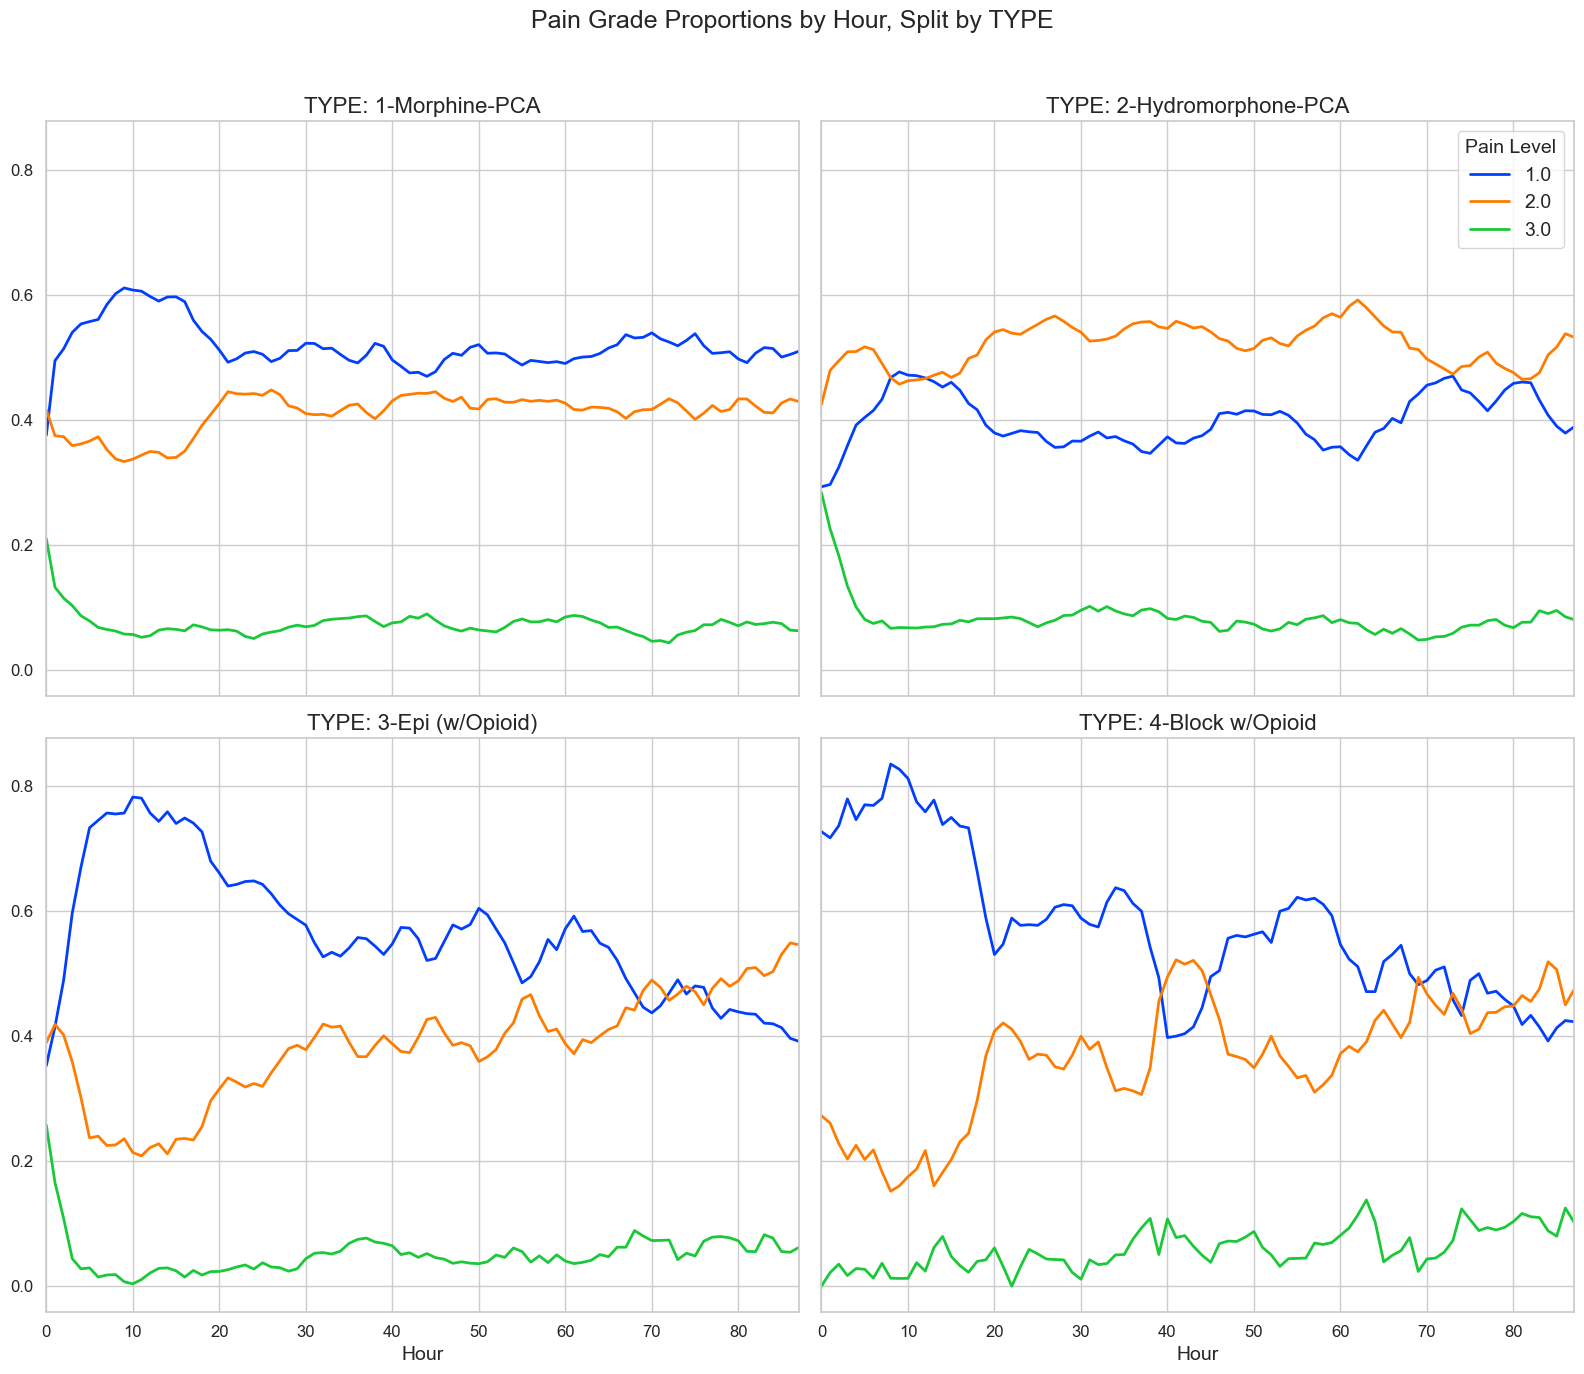

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Grade label mapping
grade_labels = {
    '1': 'Mild/None',
    '2': 'Moderate',
    '3': 'Severe',
    'UNK': 'Unknown',
    'D': 'Discharged'
}
plt.rcParams['axes.grid'] = True
# Sort TYPEs by first character
types = sorted(matrix['TYPE'].unique(), key=lambda x: str(x)[0])

# Set up 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(16, 14), sharex=True, sharey=True)
axes = axes.flatten()



for i, (ax, t) in enumerate(zip(axes, types)):
    subset = matrix[matrix['TYPE'] == t]
    grade_counts = (
        subset.groupby(['Hour', 'Grade'])
              .size()
              .unstack(fill_value=0)
              .sort_index()
    )
    grade_props = grade_counts.div(grade_counts.sum(axis=1), axis=0)
    
    grade_props.plot(ax=ax, linewidth=2, color=sns.color_palette('bright', n_colors=grade_props.shape[1]))
    
    # Format ticks and labels
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xlabel("Hour", fontsize=14)
    ax.set_ylabel("")  # Drop y-axis label
    count = type_counts.get(t, 0)
    ax.set_title(f"TYPE: {t} (n = {count})", fontsize=16)

    ax.set_title(f"TYPE: {t}", fontsize=16)
    ax.set_xlim(0, 87)
    
    # Legend only in top-left plot
    if i == 1:
        handles, labels = ax.get_legend_handles_labels()
        new_labels = [grade_labels.get(label, label) for label in labels]
        ax.legend(handles, new_labels, title="Pain Level", fontsize=14, title_fontsize=14)
    else:
        ax.get_legend().remove()

plt.suptitle("Pain Grade Proportions by Hour, Split by TYPE", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


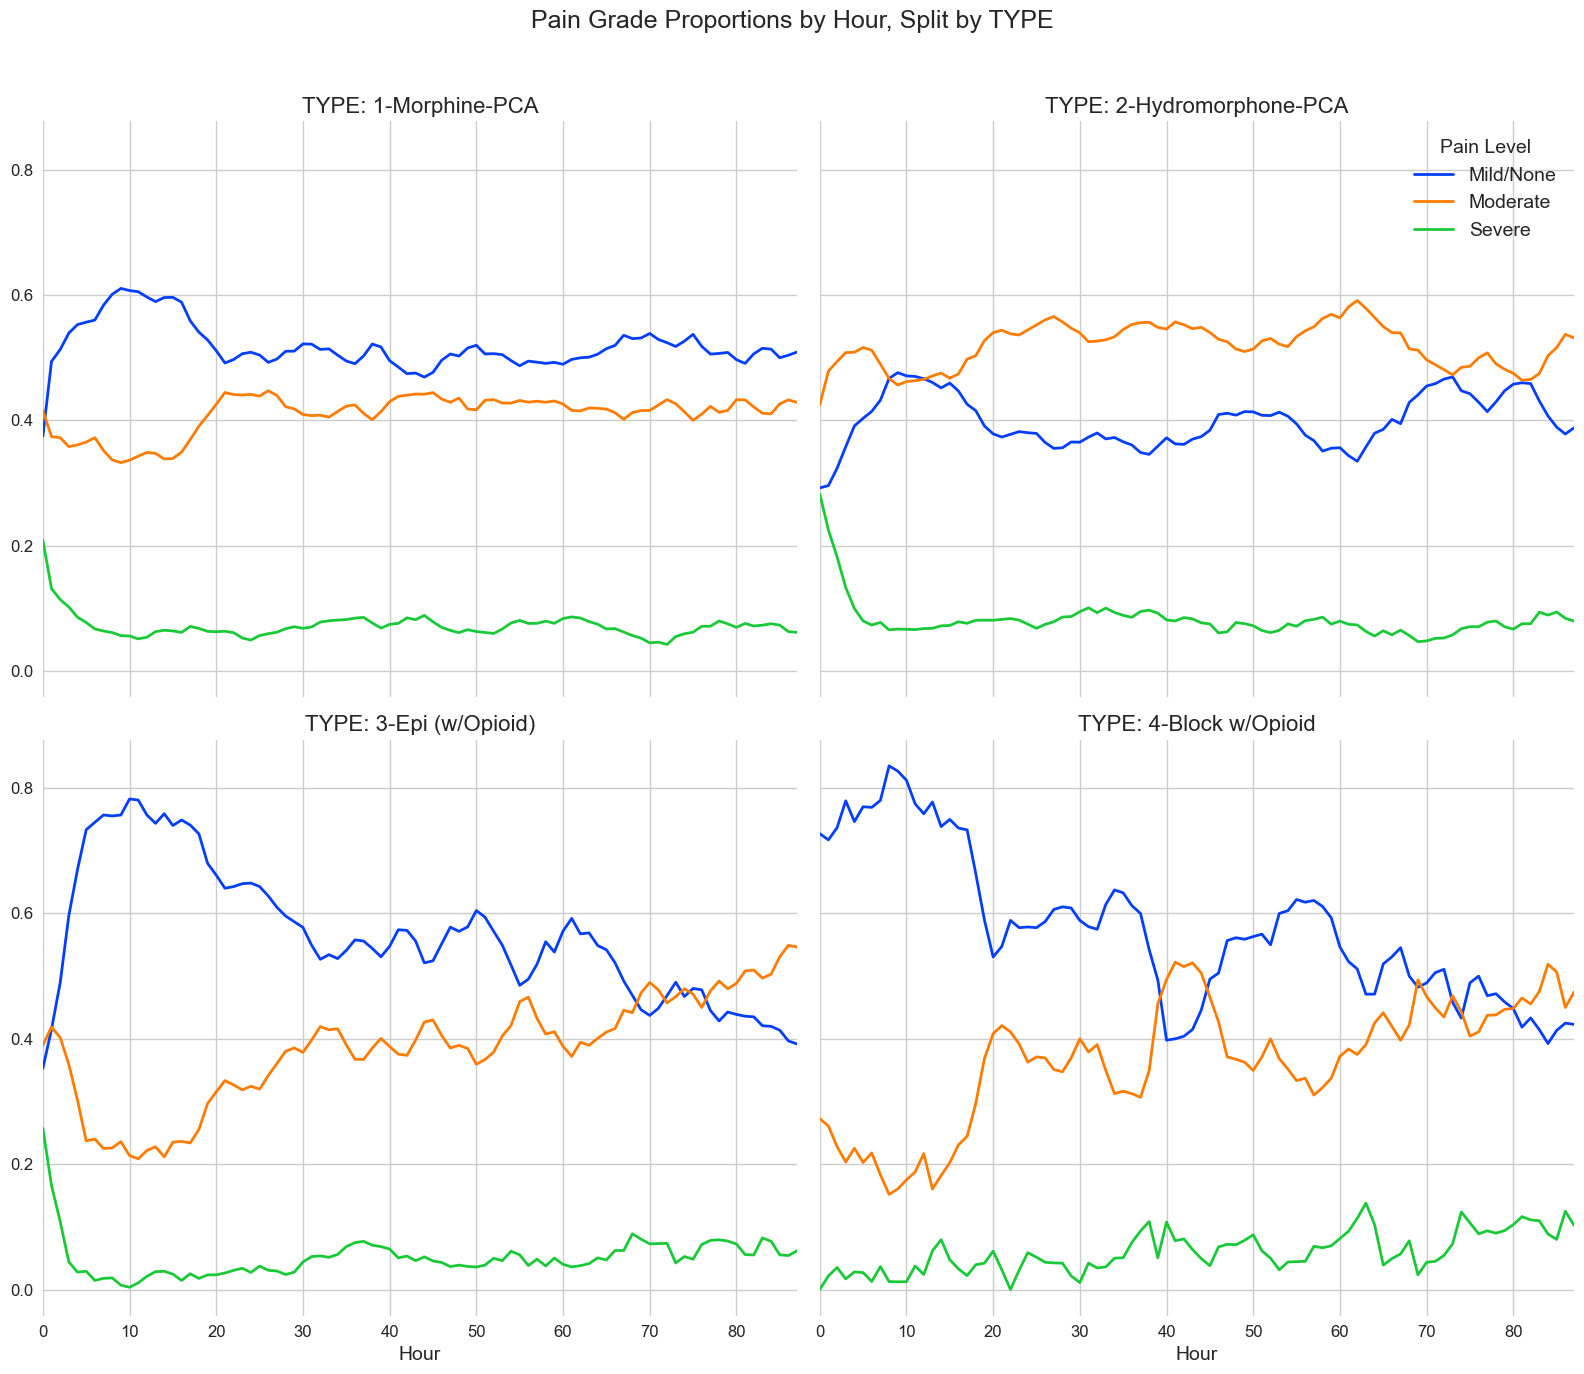

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Grade label mapping
grade_labels = {
    '1': 'Mild/None',
    '2': 'Moderate',
    '3': 'Severe'
}
plt.rcParams['axes.grid'] = True
# Sort TYPEs by first character
types = sorted(filtered['TYPE'].unique(), key=lambda x: str(x)[0])

# Set up 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(16, 14), sharex=True, sharey=True)
axes = axes.flatten()



for i, (ax, t) in enumerate(zip(axes, types)):
    subset = filtered[filtered['TYPE'] == t]
    grade_counts = (
        subset.groupby(['Hour', 'Grade'])
              .size()
              .unstack(fill_value=0)
              .sort_index()
    )
    grade_props = grade_counts.div(grade_counts.sum(axis=1), axis=0)
    
    grade_props.plot(ax=ax, linewidth=2, color=sns.color_palette('bright', n_colors=grade_props.shape[1]))
    
    # Format ticks and labels
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xlabel("Hour", fontsize=14)
    ax.set_ylabel("")  # Drop y-axis label
    ax.set_title(f"TYPE: {t}", fontsize=16)
    ax.set_xlim(0, 87)
    
    # Legend only in top-left plot
    if i == 1:
        handles, labels = ax.get_legend_handles_labels()
        new_labels = [grade_labels.get(label, label) for label in labels]
        ax.legend(handles, new_labels, title="Pain Level", fontsize=14, title_fontsize=14)
    else:
        ax.get_legend().remove()

plt.suptitle("Pain Grade Proportions by Hour, Split by TYPE", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


In [33]:
demog['TYPE'].value_counts()

TYPE
1-Morphine-PCA         1160
2-Hydromorphone-PCA     858
3-Epi (w/Opioid)        263
4-Block w/Opioid         90
Name: count, dtype: int64

In [46]:
type_counts = matrix['TYPE'].value_counts().to_dict()


In [35]:
from scipy.stats import ttest_ind
import pandas as pd

results = []

base_type = '1-Morphine-PCA'
other_types = filtered['TYPE'].unique()
other_types = [t for t in other_types if t != base_type]

for pod in filtered['POD'].unique():
    base_grades = filtered[(filtered['TYPE'] == base_type) & (filtered['POD'] == pod)]['Grade']
    
    for t in other_types:
        comp_grades = filtered[(filtered['TYPE'] == t) & (filtered['POD'] == pod)]['Grade']
        
        if len(base_grades) >= 10 and len(comp_grades) >= 10:
            stat, pval = ttest_ind(base_grades, comp_grades, equal_var=False)
            results.append({
                'Compared TYPE': t,
                'POD': pod,
                'Mean Grade (Morphine-PCA)': base_grades.mean(),
                'Mean Grade (Compared TYPE)': comp_grades.mean(),
                'p-value': round(pval, 4)
            })
        else:
            results.append({
                'Compared TYPE': t,
                'POD': pod,
                'Mean Grade (Morphine-PCA)': base_grades.mean(),
                'Mean Grade (Compared TYPE)': comp_grades.mean(),
                'p-value': 'Too few samples'
            })

results_df = pd.DataFrame(results)


In [37]:
def percent_change(row):
    base = row['Mean Grade (Morphine-PCA)']
    comp = row['Mean Grade (Compared TYPE)']
    if isinstance(base, (int, float)) and isinstance(comp, (int, float)) and base != 0:
        return round((comp - base) / base * 100, 1)
    return None

results_df['% Change'] = results_df.apply(percent_change, axis=1)


In [38]:
print(results_df.columns.tolist())


['Compared TYPE', 'POD', 'Mean Grade (Morphine-PCA)', 'Mean Grade (Compared TYPE)', 'p-value', '% Change']


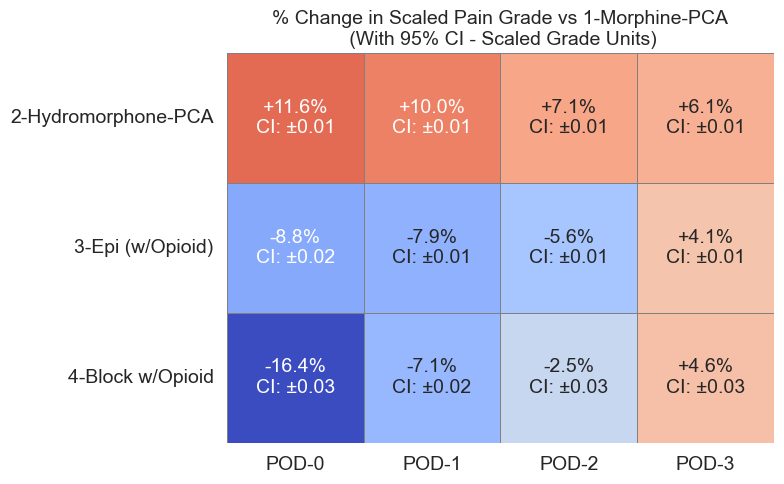

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Filter and clean Grade
filtered = matrix.copy()
filtered['Grade'] = pd.to_numeric(filtered['Grade'], errors='coerce')
filtered = filtered.dropna(subset=['Grade'])
filtered['Grade'] = filtered['Grade'].astype(int)

# Calculate mean, std, count, CI
group_stats = (
    filtered.groupby(['TYPE', 'POD'])['Grade']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
group_stats['ci'] = 1.96 * group_stats['std'] / np.sqrt(group_stats['count'])

# Extract Morphine-PCA baseline
base = group_stats[group_stats['TYPE'] == '1-Morphine-PCA'][['POD', 'mean']]
base = base.rename(columns={'mean': 'mean_base'})

# Merge and compute % change
merged = group_stats[group_stats['TYPE'] != '1-Morphine-PCA'].merge(base, on='POD')
merged['% Change'] = ((merged['mean'] - merged['mean_base']) / merged['mean_base']) * 100

# Format annotation
merged['annotation'] = merged.apply(
    lambda row: f"{row['% Change']:+.1f}%\nCI: ±{row['ci']:.2f}", axis=1
)

# Pivot for heatmap
heatmap_data = merged.pivot(index='TYPE', columns='POD', values='% Change')
annot_data = merged.pivot(index='TYPE', columns='POD', values='annotation')

# Plot heatmap
plt.figure(figsize=(8,5))
sns.heatmap(
    heatmap_data,
    annot=annot_data,
    fmt='',
    cmap='coolwarm',
    center=0,
    cbar=False,  # Suppress color scale
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"fontsize": 14}  # Increase font size inside cells
)

plt.title("% Change in Scaled Pain Grade vs 1-Morphine-PCA\n (With 95% CI - Scaled Grade Units)", fontsize=14)
plt.xlabel("", fontsize=12)
plt.ylabel("")  # Drop y-axis label
plt.yticks(fontsize = 14, rotation=0)  # Rotate y-ticks to horizontal
plt.xticks(fontsize=14,rotation=0)
plt.tight_layout()
plt.show()


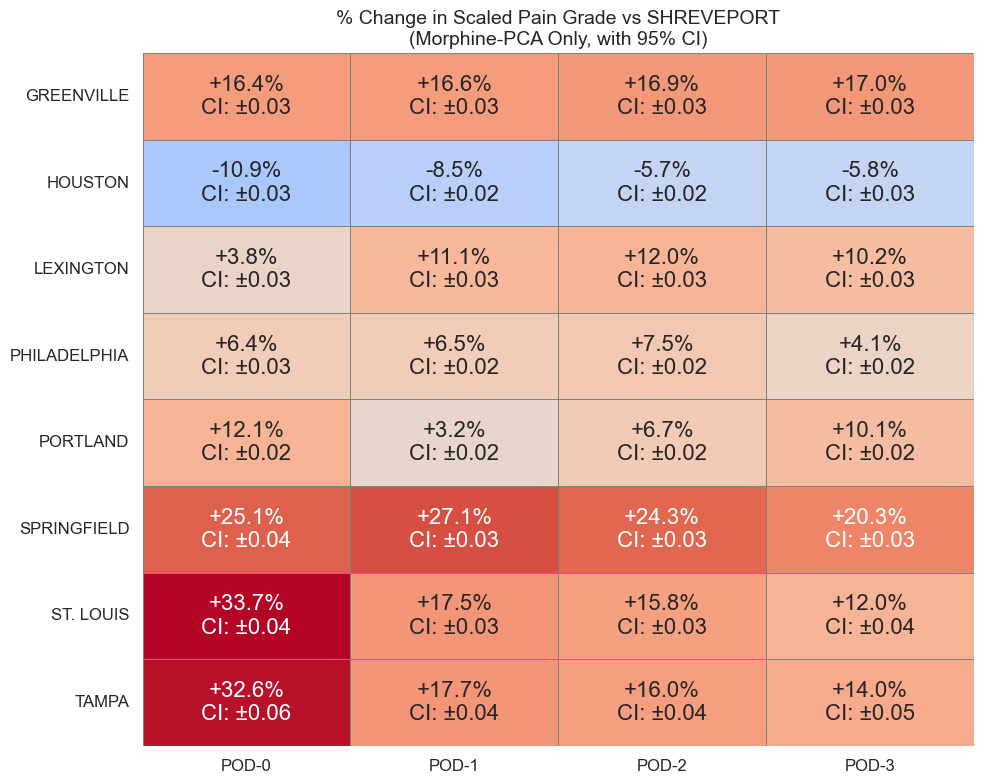

In [97]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Filter Morphine-PCA cases
morphine_only = matrix[matrix['TYPE'] == '1-Morphine-PCA'].copy()
morphine_only['Grade'] = pd.to_numeric(morphine_only['Grade'], errors='coerce')
morphine_only = morphine_only.dropna(subset=['Grade'])
morphine_only['Grade'] = morphine_only['Grade'].astype(int)

# Group stats
group_stats = (
    morphine_only.groupby(['FAC', 'POD'])['Grade']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
group_stats['ci'] = 1.96 * group_stats['std'] / np.sqrt(group_stats['count'])

# Extract SHREVEPORT baseline
base = group_stats[group_stats['FAC'] == 'SHREVEPORT'][['POD', 'mean']]
base = base.rename(columns={'mean': 'mean_base'})

# Merge and compute % change
merged = group_stats[group_stats['FAC'] != 'SHREVEPORT'].merge(base, on='POD')
merged['% Change'] = ((merged['mean'] - merged['mean_base']) / merged['mean_base']) * 100

# Format annotation
merged['annotation'] = merged.apply(
    lambda row: f"{row['% Change']:+.1f}%\nCI: ±{row['ci']:.2f}", axis=1
)

# Pivot for heatmap
heatmap_data = merged.pivot(index='FAC', columns='POD', values='% Change')
annot_data = merged.pivot(index='FAC', columns='POD', values='annotation')

# Drop facilities with no valid comparisons
heatmap_data = heatmap_data.dropna(how='all')
annot_data = annot_data.loc[heatmap_data.index]

# Optional: sort by average % Change
# Sort facilities alphabetically
row_order = sorted(heatmap_data.index)
heatmap_data = heatmap_data.loc[row_order]
annot_data = annot_data.loc[row_order]


# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    annot=annot_data,
    fmt='',
    cmap='coolwarm',
    center=0,
    cbar=False,
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"fontsize": 16}
)

plt.title("% Change in Scaled Pain Grade vs SHREVEPORT\n(Morphine-PCA Only, with 95% CI)", fontsize=14)
plt.xlabel("", fontsize=12)
plt.ylabel("", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()


In [9]:
rolling = pd.read_excel("vaps_conda7.xlsx", engine="openpyxl")
rolling.head(5)
#rolling = effectiveness ratio that is intended to visualize all OME/KG and Pain-Score data on one timeline - for every hour that
#a pain score was taken, the cumulative average of all pain scores taken for that hour, then set to an inverse (10 - cum_avg)
#to make larger values desirable. Then, for each row where this inverse value is know, it is merged with the cumulative OME/KG
#for that hour (lower numbers are better). Then, the inverse cum_avg vaps is divided by the cum OME_KG for that hour - a large
#number divided by a small number remains large; a small number divided by a larger number shrinks - because every surviving value
#is a rolling accumulation of every preceeding value, all of the information is preserved and correlated by hour. Higher values will
#show more 'bang for buck' - which Type was able to 'buy' the lowest pain scores with the OME 'money'?

,EID,POH,EFFECT_RATIO
0,15841832,1,13.155507
1,15841832,2,27.695918
2,15841832,3,29.674198
3,15841832,4,29.956809
4,15841832,5,31.157908


In [10]:
# Define the columns to bring in from demog
demog_cols = ['EID', 'GROUP', 'TYPE', 'YEAR', 'FAC', 'SEX', 'RACE', 'AGE', 'BMI', 'HW', 'ASA','DSCPOH']

# Perform the merge
rolling = rolling.merge(demog[demog_cols], on='EID', how='left')
rolling.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68228 entries, 0 to 68227
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   EID           68228 non-null  int64  
 1   POH           68228 non-null  int64  
 2   EFFECT_RATIO  68228 non-null  float64
 3   GROUP         68228 non-null  object 
 4   TYPE          68228 non-null  object 
 5   YEAR          68228 non-null  int64  
 6   FAC           68228 non-null  object 
 7   SEX           68228 non-null  object 
 8   RACE          68228 non-null  object 
 9   AGE           68228 non-null  float64
 10  BMI           68228 non-null  float64
 11  HW            68228 non-null  float64
 12  ASA           68228 non-null  int64  
 13  DSCPOH        68228 non-null  float64
dtypes: float64(5), int64(4), object(5)
memory usage: 7.3+ MB


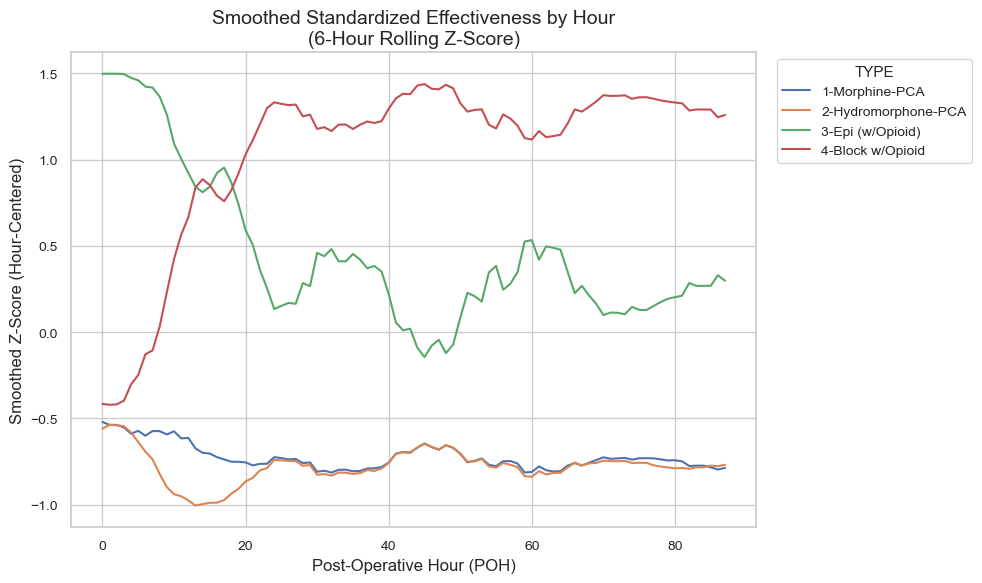

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Group by POH and TYPE, calculate mean effectiveness
hourly_avg = rolling.groupby(['POH', 'TYPE'])['EFFECT_RATIO'].mean().reset_index()

# Step 2: Z-score by POH (center each hour across TYPEs)
hourly_avg['Z_Effectiveness'] = (
    hourly_avg.groupby('POH')['EFFECT_RATIO']
    .transform(lambda x: (x - x.mean()) / x.std())
)

# Step 3: Apply 6-hour rolling average to Z-scores within each TYPE
hourly_avg['Smoothed_Z'] = (
    hourly_avg.groupby('TYPE')['Z_Effectiveness']
    .transform(lambda x: x.rolling(window=6, min_periods=1).mean())
)

# Step 4: Plot with legend outside upper left
plt.figure(figsize=(10,6))
sns.lineplot(
    data=hourly_avg,
    x='POH',
    y='Smoothed_Z',
    hue='TYPE'
)

plt.title("Smoothed Standardized Effectiveness by Hour\n(6-Hour Rolling Z-Score)", fontsize=14)
plt.xlabel("Post-Operative Hour (POH)", fontsize=12)
plt.ylabel("Smoothed Z-Score (Hour-Centered)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Move legend outside upper left
plt.legend(
    title='TYPE',
    fontsize=10,
    title_fontsize=11,
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()


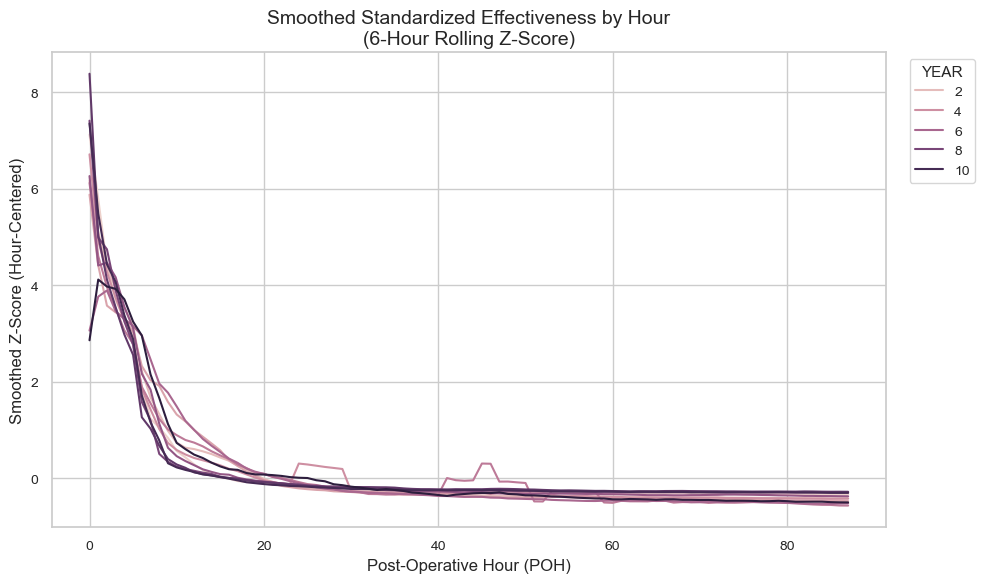

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Group by POH and TYPE, calculate mean effectiveness
hourly_avg = rolling.groupby(['POH', 'YEAR'])['EFFECT_RATIO'].mean().reset_index()

# Step 2: Z-score by POH (center each hour across TYPEs)
hourly_avg['Z_Effectiveness'] = (
    hourly_avg.groupby('YEAR')['EFFECT_RATIO']
    .transform(lambda x: (x - x.mean()) / x.std())
)

# Step 3: Apply 6-hour rolling average to Z-scores within each TYPE
hourly_avg['Smoothed_Z'] = (
    hourly_avg.groupby('YEAR')['Z_Effectiveness']
    .transform(lambda x: x.rolling(window=6, min_periods=1).mean())
)

# Step 4: Plot with legend outside upper left
plt.figure(figsize=(10,6))
sns.lineplot(
    data=hourly_avg,
    x='POH',
    y='Smoothed_Z',
    hue='YEAR'
)

plt.title("Smoothed Standardized Effectiveness by Hour\n(6-Hour Rolling Z-Score)", fontsize=14)
plt.xlabel("Post-Operative Hour (POH)", fontsize=12)
plt.ylabel("Smoothed Z-Score (Hour-Centered)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Move legend outside upper left
plt.legend(
    title='YEAR',
    fontsize=10,
    title_fontsize=11,
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()


In [13]:
hourly_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 968 entries, 0 to 967
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   POH              968 non-null    int64  
 1   YEAR             968 non-null    int64  
 2   EFFECT_RATIO     968 non-null    float64
 3   Z_Effectiveness  968 non-null    float64
 4   Smoothed_Z       968 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 37.9 KB


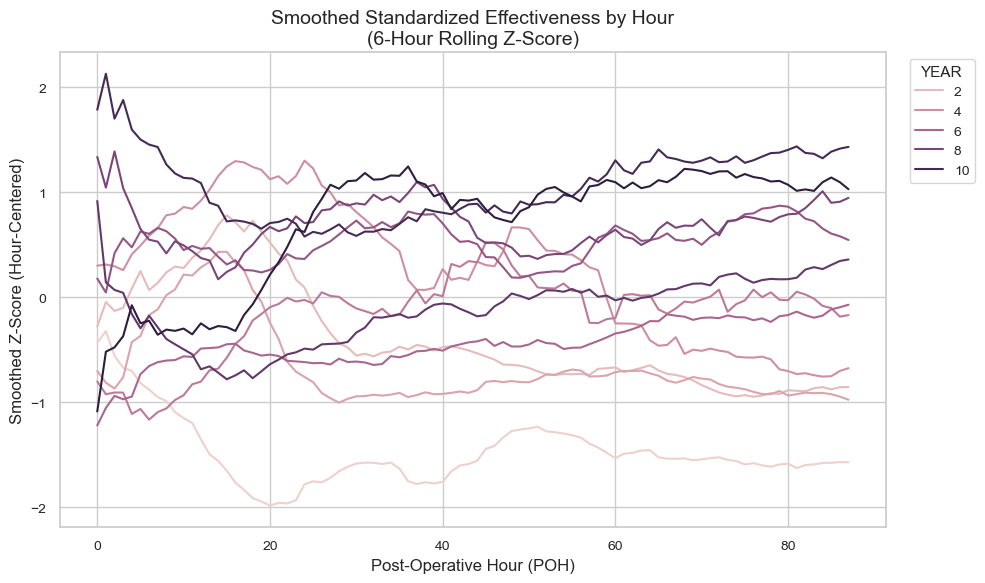

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Group by POH and TYPE, calculate mean effectiveness
hourly_avg = rolling.groupby(['POH', 'YEAR'])['EFFECT_RATIO'].mean().reset_index()

# Step 2: Z-score by POH (center each hour across TYPEs)
hourly_avg['Z_Effectiveness'] = (
    hourly_avg.groupby('POH')['EFFECT_RATIO']
    .transform(lambda x: (x - x.mean()) / x.std())
)

# Step 3: Apply 6-hour rolling average to Z-scores within each TYPE
hourly_avg['Smoothed_Z'] = (
    hourly_avg.groupby('YEAR')['Z_Effectiveness']
    .transform(lambda x: x.rolling(window=12, min_periods=1).mean())
)

# Step 4: Plot with legend outside upper left
plt.figure(figsize=(10,6))
sns.lineplot(
    data=hourly_avg,
    x='POH',
    y='Smoothed_Z',
    hue='YEAR'
)

plt.title("Smoothed Standardized Effectiveness by Hour\n(6-Hour Rolling Z-Score)", fontsize=14)
plt.xlabel("Post-Operative Hour (POH)", fontsize=12)
plt.ylabel("Smoothed Z-Score (Hour-Centered)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Move legend outside upper left
plt.legend(
    title='YEAR',
    fontsize=10,
    title_fontsize=11,
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()


In [14]:
def assign_pod(hour):
    if 0 <= hour <= 15:
        return 'POD-0'
    elif 16 <= hour <= 39:
        return 'POD-1'
    elif 40 <= hour <= 63:
        return 'POD-2'
    elif 64 <= hour <= 87:
        return 'POD-3'
    else:
        return 'Unknown'

rolling['POH'] = rolling['POH'].astype(int)
rolling['POD'] = rolling['POH'].apply(assign_pod)
rolling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68228 entries, 0 to 68227
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   EID           68228 non-null  int64  
 1   POH           68228 non-null  int32  
 2   EFFECT_RATIO  68228 non-null  float64
 3   GROUP         68228 non-null  object 
 4   TYPE          68228 non-null  object 
 5   YEAR          68228 non-null  int64  
 6   FAC           68228 non-null  object 
 7   SEX           68228 non-null  object 
 8   RACE          68228 non-null  object 
 9   AGE           68228 non-null  float64
 10  BMI           68228 non-null  float64
 11  HW            68228 non-null  float64
 12  ASA           68228 non-null  int64  
 13  DSCPOH        68228 non-null  float64
 14  POD           68228 non-null  object 
dtypes: float64(5), int32(1), int64(3), object(6)
memory usage: 7.5+ MB


In [20]:
rolling['YEAR'] = rolling['YEAR'].astype('category')
rolling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68228 entries, 0 to 68227
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   EID           68228 non-null  int64   
 1   POH           68228 non-null  int32   
 2   EFFECT_RATIO  68228 non-null  float64 
 3   GROUP         68228 non-null  object  
 4   TYPE          68228 non-null  object  
 5   YEAR          68228 non-null  category
 6   FAC           68228 non-null  object  
 7   SEX           68228 non-null  object  
 8   RACE          68228 non-null  object  
 9   AGE           68228 non-null  float64 
 10  BMI           68228 non-null  float64 
 11  HW            68228 non-null  float64 
 12  ASA           68228 non-null  int64   
 13  DSCPOH        68228 non-null  float64 
 14  POD           68228 non-null  object  
dtypes: category(1), float64(5), int32(1), int64(2), object(6)
memory usage: 7.1+ MB


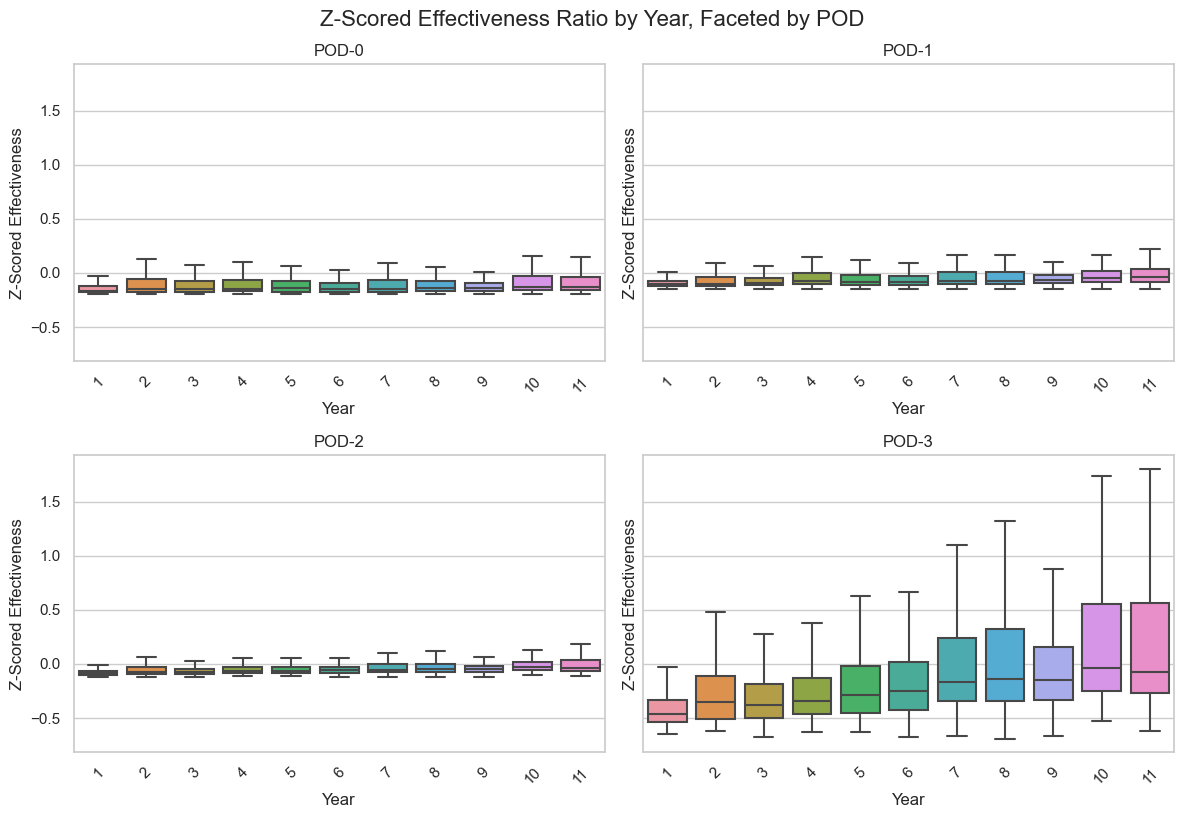

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to known PODs
subset = rolling[rolling['POD'].isin(['POD-0', 'POD-1', 'POD-2', 'POD-3'])]

daily_avg = subset.groupby(['POD', 'YEAR'])['EFFECT_RATIO'].mean().reset_index()

# Z-score EFFECT_RATIO within each POD
subset['Z_Effectiveness'] = (
    subset.groupby('POD')['EFFECT_RATIO']
    .transform(lambda x: (x - x.mean()) / x.std())
)


# Set up 2×2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

# Plot each POD
for i, pod in enumerate(['POD-0', 'POD-1', 'POD-2', 'POD-3']):
    ax = axes[i]
    sns.boxplot(
        data=subset[subset['POD'] == pod],
        x='YEAR',
        y='Z_Effectiveness',
        showfliers=False,
        ax=ax
    )
    ax.set_title(pod)
    ax.set_xlabel('Year')
    ax.set_ylabel('Z-Scored Effectiveness')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle('Z-Scored Effectiveness Ratio by Year, Faceted by POD', fontsize=16, y=1.02)
plt.show()


<Axes: xlabel='YEAR', ylabel='EFFECT_RATIO'>

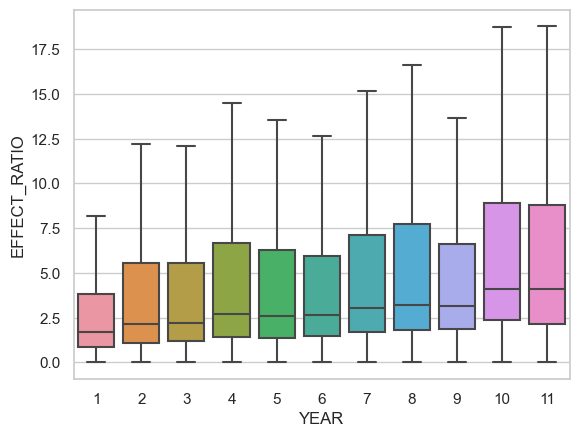

In [26]:
sns.boxplot(data=subset, x='YEAR', y='EFFECT_RATIO', showfliers=False)


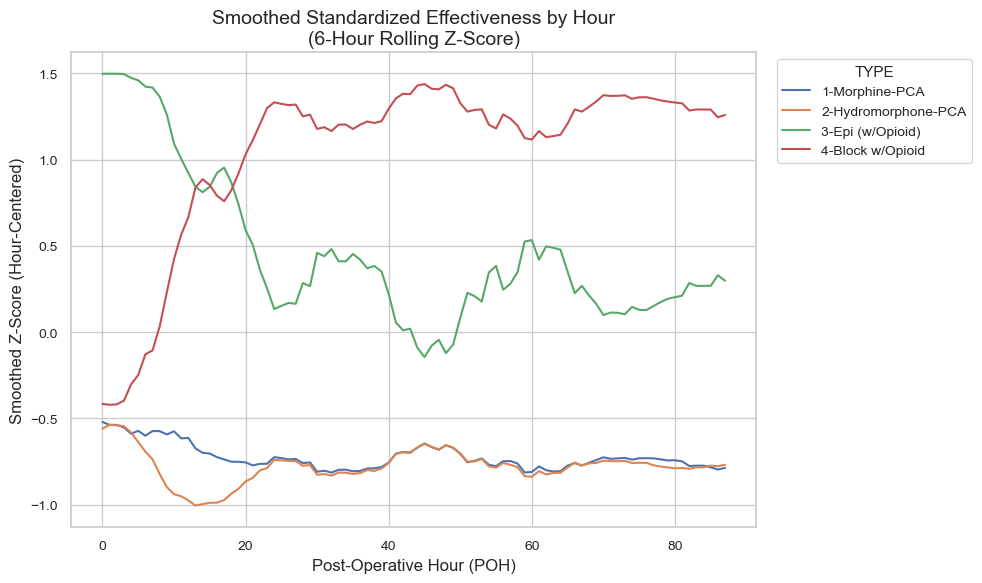

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Group by POH and TYPE, calculate mean effectiveness
hourly_avg = rolling.groupby(['POH', 'TYPE'])['EFFECT_RATIO'].mean().reset_index()

# Step 2: Z-score by POH (center each hour across TYPEs)
hourly_avg['Z_Effectiveness'] = (
    hourly_avg.groupby('POH')['EFFECT_RATIO']
    .transform(lambda x: (x - x.mean()) / x.std())
)

# Step 3: Apply 6-hour rolling average to Z-scores within each TYPE
hourly_avg['Smoothed_Z'] = (
    hourly_avg.groupby('TYPE')['Z_Effectiveness']
    .transform(lambda x: x.rolling(window=6, min_periods=1).mean())
)

# Step 4: Plot with legend outside upper left
plt.figure(figsize=(10,6))
sns.lineplot(
    data=hourly_avg,
    x='POH',
    y='Smoothed_Z',
    hue='TYPE'
)

plt.title("Smoothed Standardized Effectiveness by Hour\n(6-Hour Rolling Z-Score)", fontsize=14)
plt.xlabel("Post-Operative Hour (POH)", fontsize=12)
plt.ylabel("Smoothed Z-Score (Hour-Centered)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Move legend outside upper left
plt.legend(
    title='TYPE',
    fontsize=10,
    title_fontsize=11,
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()


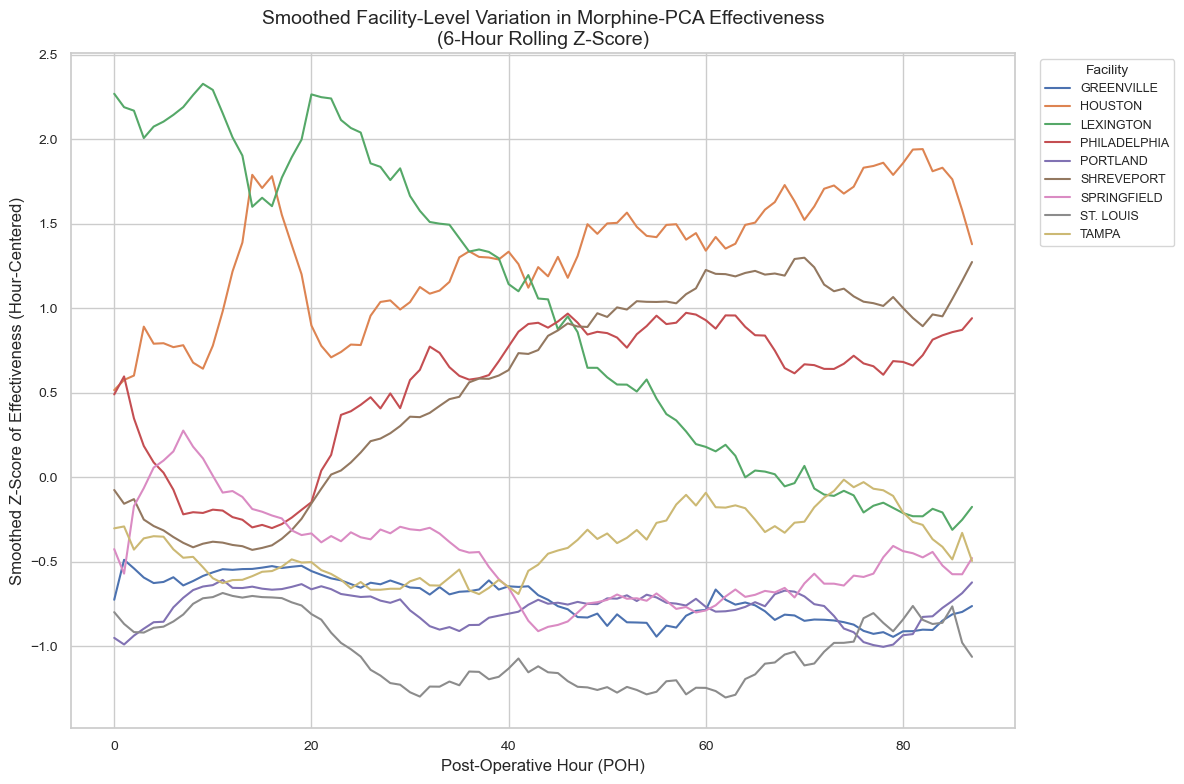

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Filter to Morphine-PCA cases only
morphine_only = rolling[rolling['TYPE'] == '1-Morphine-PCA']

# Step 2: Group by POH and FAC, calculate mean effectiveness
fac_hourly = morphine_only.groupby(['POH', 'FAC'])['EFFECT_RATIO'].mean().reset_index()

# Step 3: Z-score by POH (center each hour across facilities)
fac_hourly['Z_Effectiveness'] = (
    fac_hourly.groupby('POH')['EFFECT_RATIO']
    .transform(lambda x: (x - x.mean()) / x.std())
)

# Step 4: Apply 6-hour rolling average to Z-scores within each facility
fac_hourly['Smoothed_Z'] = (
    fac_hourly.groupby('FAC')['Z_Effectiveness']
    .transform(lambda x: x.rolling(window=6, min_periods=1).mean())
)

# Step 5: Plot smoothed Z-scores over POH by facility
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=fac_hourly,
    x='POH',
    y='Smoothed_Z',
    hue='FAC'
)

plt.title("Smoothed Facility-Level Variation in Morphine-PCA Effectiveness\n(6-Hour Rolling Z-Score)", fontsize=14)
plt.xlabel("Post-Operative Hour (POH)", fontsize=12)
plt.ylabel("Smoothed Z-Score of Effectiveness (Hour-Centered)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Facility', fontsize=9, title_fontsize=10, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [53]:
rolling['POD'] = (rolling['POH'] // 24).astype(int)


In [54]:
rolling['POD'].value_counts()


POD
0    21513
1    20454
2    18757
3     7504
Name: count, dtype: int64

In [55]:
grouped = rolling.groupby(['YEAR', 'POD'])['EFFECT_RATIO'].mean().reset_index()


In [56]:
grouped['Z_Effectiveness'] = (
    grouped.groupby('POD')['EFFECT_RATIO']
    .transform(lambda x: (x - x.mean()) / x.std())
)


In [57]:
heatmap_data = grouped.pivot(index='YEAR', columns='POD', values='Z_Effectiveness')


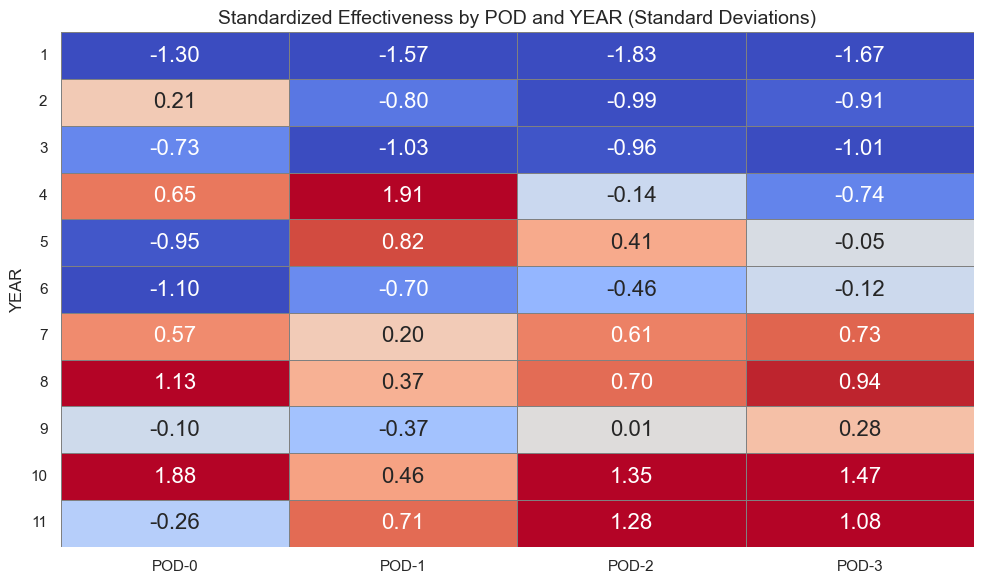

In [65]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar=False,
    annot_kws={"fontsize": 16}
)
plt.title("Standardized Effectiveness by POD and YEAR (Standard Deviations)", fontsize=14)
plt.xlabel("", fontsize=12)
plt.ylabel("YEAR", fontsize=12)
plt.yticks(rotation=0)
ax = plt.gca()
xticks = ax.get_xticklabels()
new_labels = [f"POD-{label.get_text()}" for label in xticks]
ax.set_xticklabels(new_labels, rotation=0)


plt.tight_layout()
plt.show()


In [66]:
# Sum Z-scores across PODs for each YEAR
yearly_totals = heatmap_data.sum(axis=1)

# Print the results
print("Total Standardized Effectiveness by YEAR (sum of 4 PODs):")
print(yearly_totals.round(2))


Total Standardized Effectiveness by YEAR (sum of 4 PODs):
YEAR
1    -6.37
2    -2.49
3    -3.72
4     1.69
5     0.24
6    -2.37
7     2.11
8     3.14
9    -0.18
10    5.16
11    2.80
dtype: float64


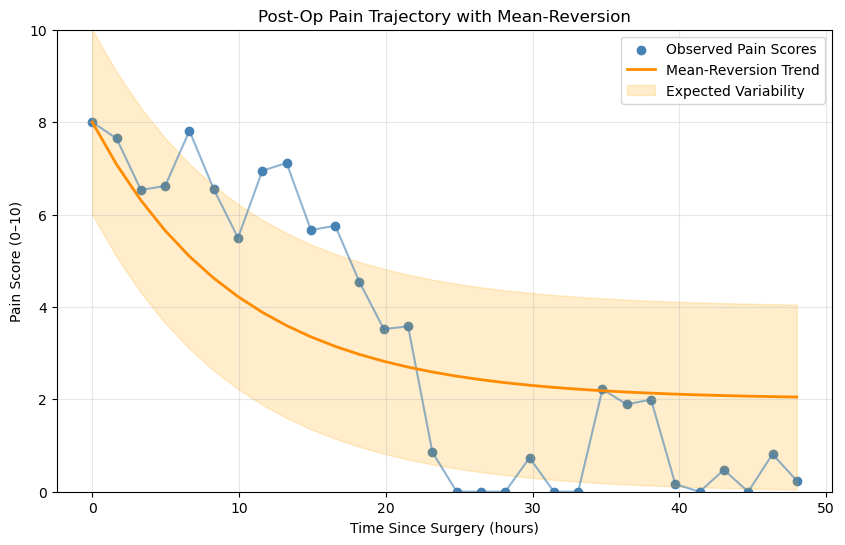

In [3]:

import numpy as np
import matplotlib.pyplot as plt

# Simulate time (hours) and pain scores with mean-reversion
np.random.seed(42)
time = np.linspace(0, 48, 30)  # 48 hours, 30 observations
mu = 2.0       # long-term mean pain
theta = 0.1    # speed of reversion
sigma = 1.0    # volatility
pain = [8.0]   # start high (post-op)
for t in time[1:]:
    dt = t - time[time.tolist().index(t)-1]
    prev = pain[-1]
    # Ornstein-Uhlenbeck step
    new = prev + theta*(mu - prev)*dt + sigma*np.sqrt(dt)*np.random.randn()
    pain.append(max(0, new))  # pain can't go below 0

# Plot observed pain
plt.figure(figsize=(10, 6))
plt.scatter(time, pain, color='steelblue', label='Observed Pain Scores')
plt.plot(time, pain, color='steelblue', alpha=0.6)

# Plot expected mean-reversion curve (deterministic part)
expected = mu + (pain[0]-mu)*np.exp(-theta*time)
plt.plot(time, expected, color='darkorange', linewidth=2, label='Mean-Reversion Trend')

# Shade confidence band (±2 SD)
upper = expected + 2*sigma
lower = np.maximum(0, expected - 2*sigma)
plt.fill_between(time, lower, upper, color='orange', alpha=0.2, label='Expected Variability')

plt.title('Post-Op Pain Trajectory with Mean-Reversion')
plt.xlabel('Time Since Surgery (hours)')
plt.ylabel('Pain Score (0–10)')
plt.ylim(0, 10)
plt.legend()
plt.grid(alpha=0.3)
plt.show()
